In [ ]:
import os
import sys
import csv
import time
import pickle
import pandas as pd
from tqdm import tqdm
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, rdFMCS, Draw
from IPython.display import display

# =====================================================================
# 1. TRIE & HASH MAP ARCHITECTURE
# =====================================================================
class TrieNode:
    def __init__(self):
        self.children = {}
        self.is_end_of_word = False

class Trie:
    def __init__(self, hash_map):
        self.root = TrieNode()
        self.hash_map = hash_map # Store hash_map locally to avoid global scope issues

    def insert(self, word):
        node = self.root
        for char in word:
            if char not in node.children:
                node.children[char] = TrieNode()
            node = node.children[char]
        node.is_end_of_word = True

    def starts_with(self, prefix):
        node = self.root
        for char in prefix:
            if char not in node.children:
                return False
            node = node.children[char]
        return True

    def store_all_fragments(self, prefix, query_smile, query_frag_id, query_id, file):
        node = self.root
        frag = []
        for char in prefix:
            node = node.children[char]
            frag.append(char)
            
        with open(file, mode='a', newline='') as database:
            writer = csv.writer(database)
            self.dfs(frag, node, prefix, writer, query_frag_id, query_smile, query_id)

    def dfs(self, frag, node, prefix, writer, query_frag_id, query_smile, query_id):
        if node.is_end_of_word:
            smile = "".join(frag[::-1][:-1])
            magnet_id = self.hash_map.get(smile, "UNKNOWN")
            # Write: [reversed_prefix, matched_magnet_frag, query_frag_id, Magnet_ID, query_smile, query_smile_id]
            writer.writerow([prefix[::-1][:-1], smile, query_frag_id, magnet_id, query_smile, query_id])
            
        for child in node.children:
            frag.append(child)
            self.dfs(frag, node.children[child], prefix, writer, query_frag_id, query_smile, query_id)
            frag.pop()

# =====================================================================
# 2. CHEMINFORMATICS & SCORING FUNCTIONS
# =====================================================================
def get_atom_count_from_smiles(smile):
    try:
        mol = Chem.MolFromSmiles(smile)
        return len(mol.GetAtoms()) if mol else 0
    except:
        return 0

def percentage_calculator(part, whole):
    return (part / whole) * 100 if whole else 0

def get_tanimoto_similarity_e(query_mol, target_mol, radius=3, nbits=1048):
    qfp = AllChem.GetMorganFingerprintAsBitVect(query_mol, radius, nBits=nbits)
    tfp = AllChem.GetMorganFingerprintAsBitVect(target_mol, radius, nBits=nbits)
    return DataStructs.TanimotoSimilarity(qfp, tfp)

def get_tanimoto_similarity_r(query_mol, target_mol):
    qfp = Chem.RDKFingerprint(query_mol)
    tfp = Chem.RDKFingerprint(target_mol)
    return DataStructs.TanimotoSimilarity(qfp, tfp)

def get_mcs_smile(query_mol, target_mol):
    mcs = rdFMCS.FindMCS([query_mol, target_mol], timeout=5)
    return Chem.MolToSmiles(Chem.MolFromSmarts(mcs.smartsString))

def get_mcs_sm_score(query_mol, target_mol):
    try:
        mcs = rdFMCS.FindMCS([query_mol, target_mol], timeout=5)
        mcs_atoms = Chem.MolFromSmarts(mcs.smartsString).GetNumAtoms()
        return mcs_atoms / target_mol.GetNumAtoms() if target_mol.GetNumAtoms() else 0
    except:
        return 0

# =====================================================================
# 3. PIPELINE STEP A: MAP FRAGMENTS (TRIE SEARCH)
# =====================================================================
def run_fragment_mapping(query_fragment_pkl, final_magnet_csv, output_mapping_csv):
    print("\n--- Step 1: Building Trie & Mapping Fragments ---")
    sys.setrecursionlimit(10000)
    hash_map = {}
    trie = Trie(hash_map)

    # 1. Build Trie from Final_MagnetDB
    print("Building Trie from MagnetDB...")
    magnet_df = pd.read_csv(final_magnet_csv)
    for _, row in magnet_df.iterrows():
        frag = str(row['Fragment'])
        if frag != 'nan':
            trie.insert((frag + "$")[::-1])
            hash_map[frag] = row['Magnet Id']

    # 2. Load query fragments
    df_query = pd.read_pickle(query_fragment_pkl)
    if 'querySMILE' not in df_query.columns and 'Canonical_SMILES' in df_query.columns:
        df_query['querySMILE'] = df_query['Canonical_SMILES']

    # 3. Search Trie
    print("Searching Trie for query fragments...")
    with open(output_mapping_csv, "w", newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["query_frag_smile", "matched_magnet_frag", "query_frag_id", "Magnet_ID", "query_smile", "query_smile_id"])

        for _, row in tqdm(df_query.iterrows(), total=len(df_query)):
            frag_smile = str(row['queryFragSMILE'])
            reversed_frag = (frag_smile + "$")[::-1]
            if trie.starts_with(reversed_frag):
                trie.store_all_fragments(
                    prefix=reversed_frag, 
                    query_smile=row['querySMILE'], 
                    query_frag_id=row['queryFragID'], 
                    query_id=row['queryID'], 
                    file=output_mapping_csv
                )
    print(f"✅ Fragment Mapping saved to {output_mapping_csv}")

# =====================================================================
# 4. PIPELINE STEP B: MAP TO TARGETS
# =====================================================================
def map_fragments_to_targets(mapping_file, final_magnet_dict_path, direct_binders_dict_path, output_file):
    print("\n--- Step 2: Mapping Fragments to Protein Targets ---")
    input_df = pd.read_csv(mapping_file)
    
    with open(final_magnet_dict_path, 'rb') as f:
        Final_MagnetDB_dict = pickle.load(f)
    with open(direct_binders_dict_path, 'rb') as f:
        direct_binders_dict = pickle.load(f)

    start = time.time()
    absent_source_ids = []

    with open(output_file, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow([
            "Database_ID", "original_ligand_smile", "Target_ID", "query_frag_ID", 
            "query_frag_smile", "matched_magnet_frag", "Magnet_ID", "query_smile", 
            "query_ID", "query_smile_atom_count", "Query_Percentage", "Target_Percentage"
        ])

        for _, row in tqdm(input_df.iterrows(), total=len(input_df)):
            magnet_id = row['Magnet_ID']
            if magnet_id not in Final_MagnetDB_dict:
                continue

            source_ids = Final_MagnetDB_dict[magnet_id].get('Source datbase IDs', [])
            query_smile_atom_count = get_atom_count_from_smiles(row['query_smile'])
            query_frag_atom_count = get_atom_count_from_smiles(row['query_frag_smile'])
            target_frag_atom_count = get_atom_count_from_smiles(row['matched_magnet_frag'])

            for source_id in source_ids:
                if source_id not in direct_binders_dict:
                    absent_source_ids.append(source_id)
                    continue

                target_id = direct_binders_dict[source_id]['Target ID']
                original_smile = direct_binders_dict[source_id]['SMILE']
                target_smile_atom_count = get_atom_count_from_smiles(original_smile)

                query_percent = percentage_calculator(query_frag_atom_count, query_smile_atom_count)
                target_percent = percentage_calculator(target_frag_atom_count, target_smile_atom_count)

                writer.writerow([
                    source_id, original_smile, target_id, row['query_frag_id'],
                    row['query_frag_smile'], row['matched_magnet_frag'], magnet_id,
                    row['query_smile'], row['query_smile_id'], query_smile_atom_count,
                    query_percent, target_percent
                ])

    print(f"✅ Target Mapping complete in {time.time() - start:.2f}s. Saved to {output_file}")

# =====================================================================
# 5. PIPELINE STEP C: FILTERING & VISUALIZATION
# =====================================================================
def filter_and_highlight(mapped_db_csv):
    print("\n--- Step 3: Threshold Filtering & Visualization ---")
    df = pd.read_csv(mapped_db_csv)
    
    # Apply your specific thresholds
    print(f"Initial row count: {len(df)}")
    df = df[df['query_smile_atom_count'] >= 10]
    df = df[df["Query_Percentage"] >= 25]
    final_filtered_df = df[df["Target_Percentage"] >= 75]
    print(f"Row count after stringent filtering: {len(final_filtered_df)}")
    
    # Quick Visualization of top 5 matches
    print("\nHighlighting Maximum Common Substructures (MCS) for top hits...")
    for _, row in final_filtered_df.head(5).iterrows():
        query_mol = Chem.MolFromSmiles(row['query_frag_smile'])
        target_mol = Chem.MolFromSmiles(row['matched_magnet_frag'])
        
        if query_mol and target_mol:
            mcs = rdFMCS.FindMCS([query_mol, target_mol], timeout=10, ringMatchesRingOnly=True, completeRingsOnly=True)
            if mcs.smartsString:
                mcs_mol = Chem.MolFromSmarts(mcs.smartsString)
                img = Draw.MolsToGridImage(
                    [query_mol, target_mol],
                    highlightAtomLists=[list(query_mol.GetSubstructMatch(mcs_mol)), list(target_mol.GetSubstructMatch(mcs_mol))],
                    legends=["Query Fragment", f"Target Match (Magnet ID: {row['Magnet_ID']})"],
                    molsPerRow=2,
                    subImgSize=(350, 350)
                )
                display(img)

# =====================================================================
# EXECUTION ROUTINE
# =====================================================================
if __name__ == "__main__":
    
    # Define File Paths
    QUERY_FRAGMENTS_PKL = "/storage/savi/saveenas/Projects/Magnet/Magnet_Package/Imppat_fragments_filtered.pkl"
    FINAL_MAGNET_CSV = "/storage/savi/saveenas/Projects/Magnet/Dataset/FINAL_MAGNET_DATABASE/Final_MagnetDB.csv"
    
    MAGNET_DICT_PKL = "/storage/savi/saveenas/Projects/Magnet/Magnet_Package/Working_Module_2/Workflow/data/Final_MagnetDB_Dictionary.pkl"
    DIRECT_BINDERS_PKL = "Direct_Binders_Dictionary.pkl"
    
    # Output Files
    MAPPING_CSV = "Query_Magnet_Mapping.csv"
    TARGET_MAPPED_CSV = "query_magnet_source_db_mapping.csv"

    # 1. Search Trie
    run_fragment_mapping(
        query_fragment_pkl=QUERY_FRAGMENTS_PKL, 
        final_magnet_csv=FINAL_MAGNET_CSV, 
        output_mapping_csv=MAPPING_CSV
    )
    
    # 2. Map to Targets
    map_fragments_to_targets(
        mapping_file=MAPPING_CSV,
        final_magnet_dict_path=MAGNET_DICT_PKL,
        direct_binders_dict_path=DIRECT_BINDERS_PKL,
        output_file=TARGET_MAPPED_CSV
    )
    
    # 3. Filter and Show High-Quality Hits
    filter_and_highlight(TARGET_MAPPED_CSV)


--- Step 1: Building Trie & Mapping Fragments ---
Building Trie from MagnetDB...


# enriched trie 

In [9]:
import os
import sys
import time
import pickle
import pandas as pd
from tqdm import tqdm

# --- 1. Your Database Paths ---
FINAL_MAGNET_CSV = "/storage/savi/saveenas/Projects/Magnet/Dataset/FINAL_MAGNET_DATABASE/Final_MagnetDB.csv"
DIRECT_BINDERS_PKL = "/storage/savi/saveenas/Projects/Magnet/Magnet_Package/Direct_Binders_Dictionary.pkl"
OUTPUT_TRIE_PKL = "Enriched_MagnetDB_Trie.pkl"

# --- Increase Python's Recursion Limit for Deep Tries ---
sys.setrecursionlimit(5000000)

# --- 2. Trie Architecture ---
class TrieNode:
    def __init__(self):
        self.children = {}
        self.is_end_of_word = False
        self.metadata = [] 

class EnrichedTrie:
    def __init__(self):
        self.root = TrieNode()

    def insert(self, word, metadata_payload):
        node = self.root
        for char in word:
            if char not in node.children:
                node.children[char] = TrieNode()
            node = node.children[char]
        node.is_end_of_word = True
        node.metadata.extend(metadata_payload)

    def __getstate__(self):
        return self.root

    def __setstate__(self, state):
        self.root = state

# --- 3. Ultra-Fast Build Logic ---
if __name__ == "__main__":
    start = time.time()
    print("Loading Databases...")
    
    # Load data
    magnet_df = pd.read_csv(FINAL_MAGNET_CSV)
    with open(DIRECT_BINDERS_PKL, 'rb') as f:
        direct_binders_dict = pickle.load(f)

    trie = EnrichedTrie()
    
    print("Converting columns to lists for ultra-fast C-level iteration...")
    fragments = magnet_df['Fragment'].astype(str).tolist()
    magnet_ids = magnet_df['Magnet Id'].astype(str).tolist()
    sources = magnet_df['Source'].astype(str).tolist()

    print("Building Enriched Trie...")
    for frag, magnet_id, source_str in tqdm(zip(fragments, magnet_ids, sources), total=len(fragments)):
        if frag == 'nan' or not frag: 
            continue
            
        source_ids = source_str.split(', ') if source_str != 'nan' else []
        
        payload = []
        for source_id in source_ids:
            if source_id in direct_binders_dict:
                target_info = direct_binders_dict[source_id]
                payload.append({
                    "Database_ID": source_id,
                    "Target_ID": target_info.get('Target ID', ''),
                    "Original_SMILES": target_info.get('SMILE', ''),
                    "Magnet_ID": magnet_id
                })
        
        if payload:
            trie.insert((frag + "$")[::-1], payload)
            
    print("Serializing Trie to disk (with expanded recursion limit)...")
    with open(OUTPUT_TRIE_PKL, 'wb') as f:
        pickle.dump(trie, f, protocol=pickle.HIGHEST_PROTOCOL)
        
    print(f"✅ Trie built & saved successfully in {time.time() - start:.2f} seconds!")

Loading Databases...
Converting columns to lists for ultra-fast C-level iteration...
Building Enriched Trie...


100%|██████████| 2471351/2471351 [04:26<00:00, 9286.80it/s] 


Serializing Trie to disk (with expanded recursion limit)...
✅ Trie built & saved successfully in 488.09 seconds!


In [12]:
import csv
import time
import pickle
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Recap

# =================================================================
# 1. DEFINE CLASSES LOCALLY (Fixes the Jupyter Import Error)
# =================================================================
class TrieNode:
    def __init__(self):
        self.children = {}
        self.is_end_of_word = False
        self.metadata = [] 

class EnrichedTrie:
    def __init__(self):
        self.root = TrieNode()

    def __getstate__(self):
        return self.root

    def __setstate__(self, state):
        self.root = state

# =================================================================
# 2. INFERENCE LOGIC
# =================================================================
def get_atom_count(smile):
    try:
        mol = Chem.MolFromSmiles(smile)
        return mol.GetNumAtoms() if mol else 0
    except:
        return 0

def predict_targets(user_smiles, query_name="User_Molecule", min_query_cov=25.0, min_target_cov=75.0):
    print(f"\n{'='*50}\n🔍 SYNGLUE INFERENCE: {query_name}\n{'='*50}")
    
    print("Loading Enriched Trie into memory...")
    t0_load = time.time()
    
    # Python will use the EnrichedTrie class we defined right above to unpack this!
    with open("Enriched_MagnetDB_Trie.pkl", "rb") as f:
        trie = pickle.load(f)
        
    print(f"✅ Trie loaded in: {time.time() - t0_load:.4f} seconds.")
    
    print("\nProcessing User SMILES...")
    t0_inference = time.time()
    
    mol = Chem.MolFromSmiles(user_smiles)
    if not mol:
        print("❌ Error: Invalid SMILES.")
        return None

    hierarchy = Recap.RecapDecompose(mol)
    terminal_fragments = [smi for smi, node in hierarchy.children.items() if smi.count('*') == 1]
    
    q_smile_atoms = get_atom_count(user_smiles)
    results = []

    for frag in terminal_fragments:
        node = trie.root
        match_found = True
        
        for char in (frag + "$")[::-1]:
            if char not in node.children:
                match_found = False
                break
            node = node.children[char]
            
        if match_found and node.is_end_of_word:
            q_frag_atoms = get_atom_count(frag)
            
            for metadata in node.metadata:
                t_smile_atoms = get_atom_count(metadata["Original_SMILES"])
                
                q_cov = (q_frag_atoms / q_smile_atoms) * 100 if q_smile_atoms else 0
                t_cov = (q_frag_atoms / t_smile_atoms) * 100 if t_smile_atoms else 0
                
                if q_cov >= min_query_cov and t_cov >= min_target_cov:
                    results.append({
                        "Database_ID": metadata["Database_ID"],
                        "Target_ID": metadata["Target_ID"],
                        "Magnet_ID": metadata["Magnet_ID"],
                        "query_frag_smile": frag,
                        "matched_magnet_frag": frag, 
                        "original_target_smile": metadata["Original_SMILES"],
                        "query_smile_atom_count": q_smile_atoms,
                        "Query_Percentage": round(q_cov, 2),
                        "Target_Percentage": round(t_cov, 2)
                    })

    df_results = pd.DataFrame(results)
    print(f"⚡ Inference completed in: {time.time() - t0_inference:.5f} seconds!")
    
    if df_results.empty:
        print(f"⚠️ No targets found passing the {min_query_cov}%/{min_target_cov}% thresholds.")
    else:
        df_results = df_results.sort_values(by="Target_Percentage", ascending=False).reset_index(drop=True)
        print(f"🎯 Found {len(df_results)} high-confidence target matches!\n")
        
        out_csv = f"{query_name}_Mapped_Targets.csv"
        df_results.to_csv(out_csv, index=False)
        print(f"💾 Full results saved to {out_csv}")
        
    return df_results

# Test it out!
if __name__ == "__main__":
    # Testing Imatinib with strict biological thresholds
    IMATINIB_SMILES = "CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C)NC4=NC=CC(=N4)C5=CN=CC=C5"
    predict_targets(user_smiles=IMATINIB_SMILES, query_name="Imatinib", min_query_cov=25.0, min_target_cov=75.0)


🔍 SYNGLUE INFERENCE: Imatinib
Loading Enriched Trie into memory...
✅ Trie loaded in: 184.3380 seconds.

Processing User SMILES...
⚡ Inference completed in: 44.61557 seconds!
🎯 Found 9639 high-confidence target matches!

💾 Full results saved to Imatinib_Mapped_Targets.csv


In [13]:
import pandas as pd

def load_and_aggregate_results(csv_path):
    print(f"Loading raw inference results from {csv_path}...")
    df = pd.read_csv(csv_path)
    print(f"Total raw matches found: {len(df)}")
    
    # ---------------------------------------------------------
    # 1. Aggregate by Unique Target & Fragment
    # ---------------------------------------------------------
    # We group by the Target and the Fragment to see exactly how many 
    # different databases/assays (Evidence Count) confirm this exact match.
    aggregated_df = df.groupby(['Target_ID', 'query_frag_smile', 'original_target_smile']).agg({
        'Database_ID': 'nunique',       # Count how many unique source DBs confirm this hit
        'Magnet_ID': 'first',           # Keep the Magnet ID
        'Query_Percentage': 'max',      # Keep the best query coverage
        'Target_Percentage': 'max'      # Keep the best target coverage
    }).reset_index()
    
    # Rename for clarity
    aggregated_df.rename(columns={'Database_ID': 'Evidence_Count'}, inplace=True)
    
    # Sort by the most confident hits (Highest Target % and Highest Evidence)
    aggregated_df = aggregated_df.sort_values(
        by=['Target_Percentage', 'Query_Percentage', 'Evidence_Count'], 
        ascending=[False, False, False]
    ).reset_index(drop=True)
    
    print(f"Total UNIQUE target-fragment interactions: {len(aggregated_df)}")
    
    return aggregated_df

# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    results_file = "Imatinib_Mapped_Targets.csv"
    
    # Load and clean the data
    imatinib_targets = load_and_aggregate_results(results_file)
    
    # Display the absolute best, most-confirmed targets
    print("\n--- Top 10 Unique Protein Targets for Imatinib ---")
    print(imatinib_targets[['Target_ID', 'Query_Percentage', 'Target_Percentage', 'Evidence_Count']].head(10).to_string())

Loading raw inference results from Imatinib_Mapped_Targets.csv...
Total raw matches found: 9639
Total UNIQUE target-fragment interactions: 643

--- Top 10 Unique Protein Targets for Imatinib ---
            Target_ID  Query_Percentage  Target_Percentage  Evidence_Count
0   Yeast_STITCH_T_11             67.57             147.06               1
1   Yeast_STITCH_T_11             86.49             133.33               1
2   Yeast_STITCH_T_11             83.78             129.17               1
3  Yeast_STITCH_T_705             35.14             118.18               1
4   Yeast_STITCH_T_11             86.49             114.29               1
5   Yeast_STITCH_T_11             67.57             108.70               1
6   Yeast_STITCH_T_11             67.57             104.17               1
7   Yeast_STITCH_T_11             67.57             104.17               1
8   Yeast_STITCH_T_11             45.95             100.00               1
9   Yeast_STITCH_T_11             67.57              96

Loading data from Imatinib_Mapped_Targets.csv...
Initial rows: 9639
Rows surviving filters: 9631
--- Running Type Analysis ---

Highlighting Top 3 Maximum Common Substructures (MCS)...
----------------------------------------------------------------------
Target ID: Yeast_STITCH_T_11 | Type: Type 2
Query Functional Groups:  carbonyl compound (1), tertiary amine (2)
Target Functional Groups: carbonyl compound (1), ketone (1), amide (1), halogen (1), alkene (1), pyrrole (1)


[15:35:14] SMARTS Parse Error: syntax error while parsing: C=N-OH
[15:35:14] SMARTS Parse Error: Failed parsing SMARTS 'C=N-OH' for input: 'C=N-OH'
[15:35:14] SMARTS Parse Error: syntax error while parsing: N-H
[15:35:14] SMARTS Parse Error: Failed parsing SMARTS 'N-H' for input: 'N-H'
[15:35:14] SMARTS Parse Error: syntax error while parsing: N-R
[15:35:14] SMARTS Parse Error: Failed parsing SMARTS 'N-R' for input: 'N-R'
[15:35:14] SMARTS Parse Error: syntax error while parsing: O-H
[15:35:14] SMARTS Parse Error: Failed parsing SMARTS 'O-H' for input: 'O-H'
[15:35:14] SMARTS Parse Error: syntax error while parsing: C-SH
[15:35:14] SMARTS Parse Error: Failed parsing SMARTS 'C-SH' for input: 'C-SH'
[15:35:14] SMARTS Parse Error: syntax error while parsing: S(=O)(=O)OH
[15:35:14] SMARTS Parse Error: Failed parsing SMARTS 'S(=O)(=O)OH' for input: 'S(=O)(=O)OH'
[15:35:14] SMARTS Parse Error: syntax error while parsing: C=N-OH
[15:35:14] SMARTS Parse Error: Failed parsing SMARTS 'C=N-OH' fo

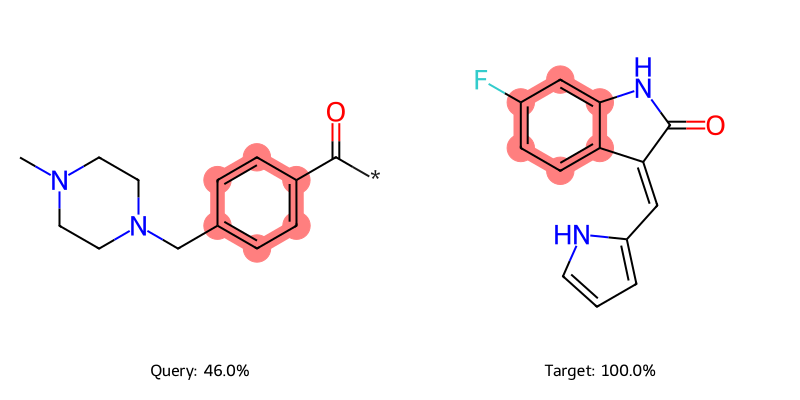

----------------------------------------------------------------------
Target ID: Yeast_STITCH_T_11 | Type: Type 2
Query Functional Groups:  carbonyl compound (1), amide (1), tertiary amine (2)
Target Functional Groups: carbonyl compound (1), amide (1), pyridine (2)


[15:35:14] SMARTS Parse Error: syntax error while parsing: C=N-OH
[15:35:14] SMARTS Parse Error: Failed parsing SMARTS 'C=N-OH' for input: 'C=N-OH'
[15:35:14] SMARTS Parse Error: syntax error while parsing: N-H
[15:35:14] SMARTS Parse Error: Failed parsing SMARTS 'N-H' for input: 'N-H'
[15:35:14] SMARTS Parse Error: syntax error while parsing: N-R
[15:35:14] SMARTS Parse Error: Failed parsing SMARTS 'N-R' for input: 'N-R'
[15:35:14] SMARTS Parse Error: syntax error while parsing: O-H
[15:35:14] SMARTS Parse Error: Failed parsing SMARTS 'O-H' for input: 'O-H'
[15:35:14] SMARTS Parse Error: syntax error while parsing: C-SH
[15:35:14] SMARTS Parse Error: Failed parsing SMARTS 'C-SH' for input: 'C-SH'
[15:35:14] SMARTS Parse Error: syntax error while parsing: S(=O)(=O)OH
[15:35:14] SMARTS Parse Error: Failed parsing SMARTS 'S(=O)(=O)OH' for input: 'S(=O)(=O)OH'
[15:35:14] SMARTS Parse Error: syntax error while parsing: C=N-OH
[15:35:14] SMARTS Parse Error: Failed parsing SMARTS 'C=N-OH' fo

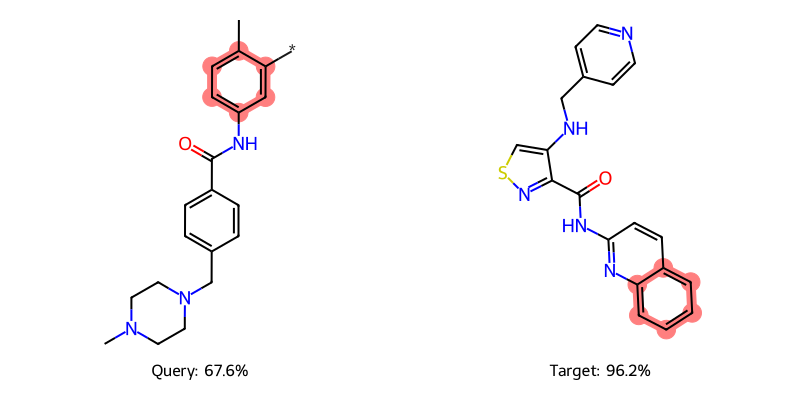

----------------------------------------------------------------------
Target ID: SMS_T_208 | Type: Type 2
Query Functional Groups:  pyridine (1), pyrimidine (1)
Target Functional Groups: carbonyl compound (1), ketone (1), amide (1), pyridine (1), pyrimidine (1)


[15:35:14] SMARTS Parse Error: syntax error while parsing: C=N-OH
[15:35:14] SMARTS Parse Error: Failed parsing SMARTS 'C=N-OH' for input: 'C=N-OH'
[15:35:14] SMARTS Parse Error: syntax error while parsing: N-H
[15:35:14] SMARTS Parse Error: Failed parsing SMARTS 'N-H' for input: 'N-H'
[15:35:14] SMARTS Parse Error: syntax error while parsing: N-R
[15:35:14] SMARTS Parse Error: Failed parsing SMARTS 'N-R' for input: 'N-R'
[15:35:14] SMARTS Parse Error: syntax error while parsing: O-H
[15:35:14] SMARTS Parse Error: Failed parsing SMARTS 'O-H' for input: 'O-H'
[15:35:14] SMARTS Parse Error: syntax error while parsing: C-SH
[15:35:14] SMARTS Parse Error: Failed parsing SMARTS 'C-SH' for input: 'C-SH'
[15:35:14] SMARTS Parse Error: syntax error while parsing: S(=O)(=O)OH
[15:35:14] SMARTS Parse Error: Failed parsing SMARTS 'S(=O)(=O)OH' for input: 'S(=O)(=O)OH'
[15:35:14] SMARTS Parse Error: syntax error while parsing: C=N-OH
[15:35:14] SMARTS Parse Error: Failed parsing SMARTS 'C=N-OH' fo

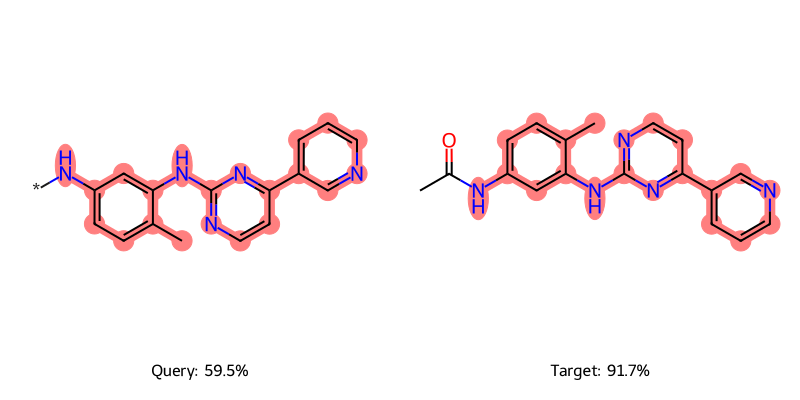

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Draw, rdFMCS, Recap
from rdkit.Chem.Draw import rdDepictor
from IPython.display import display

# =====================================================================
# 1. VISUALIZATION STYLING (User Custom Params)
# =====================================================================
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "axes.linewidth": 1.0,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out"
})

# =====================================================================
# 2. MASTER CHEMICAL GROUPS DICTIONARY 
# =====================================================================
MASTER_CHEMICAL_GROUPS = {
    'cation': {'smarts': '[+]'},
    'anion': {'smarts': '[-]'},
    'carbonyl compound': {'smarts': 'C=O'},
    'ketone': {'smarts': 'C(=O)C'},
    'thiocarbonyl compound': {'smarts': 'C=S'},
    'imine': {'smarts': 'C=N'},
    'hydrazone': {'smarts': 'C=N-N'},
    'oxime': {'smarts': 'C=N-OH'},
    'ether': {'smarts': 'C-O-C'},
    'carboxylic acid': {'smarts': 'C(=O)O'},
    'ester': {'smarts': 'C(=O)O-C'},
    'amide': {'smarts': 'C(=O)N'},
    'primary amine': {'smarts': 'N-H'},
    'secondary amine': {'smarts': 'N-R'},
    'tertiary amine': {'smarts': 'N(C)(C)C'},
    'alcohol': {'smarts': 'O-H'},
    'phenol': {'smarts': 'c1ccccc1O'},
    'thiol': {'smarts': 'C-SH'},
    'thioether': {'smarts': 'C-S-C'},
    'disulfide': {'smarts': 'S-S'},
    'sulfonamide': {'smarts': 'S(=O)(=O)N'},
    'sulfone': {'smarts': 'S(=O)(=O)C'},
    'sulfonic acid': {'smarts': 'S(=O)(=O)OH'},
    'phosphate': {'smarts': 'O=P(O)(O)O'},
    'halogen': {'smarts': '[F,Cl,Br,I]'},
    'trifluoromethyl': {'smarts': 'C(F)(F)F'},
    'cyanide / nitrile': {'smarts': 'C#N'},
    'nitro': {'smarts': 'N(=O)=O'},
    'azide': {'smarts': 'N=N=N'},
    'alkyne': {'smarts': 'C#C'},
    'alkene': {'smarts': 'C=C'},
    'furan': {'smarts': 'c1cocc1'},
    'thiophene': {'smarts': 'c1cscc1'},
    'pyrrole': {'smarts': 'c1cc[nH]c1'},
    'pyridine': {'smarts': 'c1ccncc1'},
    'pyrimidine': {'smarts': 'c1cncnc1'},
    'imidazole': {'smarts': 'c1c[nH]cn1'},
    'pyrazole': {'smarts': 'c1c[nH]nc1'},
}

def identify_functional_groups(mol):
    """Safely extracts functional groups using RDKit SMARTS matching."""
    detected = []
    for name, properties in MASTER_CHEMICAL_GROUPS.items():
        pattern = Chem.MolFromSmarts(properties['smarts'])
        if pattern is None:
            continue 
            
        matches = mol.GetSubstructMatches(pattern)
        if matches:
            detected.append(f"{name} ({len(matches)})")
            
    return ", ".join(detected) if detected else "None"

# =====================================================================
# 3. POLYPHARMACOLOGY TYPE ANALYSIS (1-5)
# =====================================================================
def get_mcs_smile(query_mol, target_mol):
    if query_mol is None or target_mol is None: return None
    mcs = rdFMCS.FindMCS([query_mol, target_mol], timeout=3)
    if mcs is None or not mcs.smartsString: return None
    return Chem.MolToSmiles(Chem.MolFromSmarts(mcs.smartsString), isomericSmiles=True)

def perform_type_analysis(df, parent_smiles):
    """Calculates Type 1-5 Polypharmacology based on RECAP S1/S2 mapping."""
    print("--- Running Type Analysis ---")
    
    unique_queries = set(df['query_frag_smile'].unique())
    unique_target_count = df['Target_ID'].nunique()
    
    molecule = Chem.MolFromSmiles(parent_smiles)
    hierarchy = Recap.RecapDecompose(molecule)
    first_level_keys = sorted(hierarchy.children.keys())

    # If the molecule doesn't fragment enough
    if len(first_level_keys) < 2:
        df['Polypharmacology_Type'] = "Type 1" if unique_target_count == 1 else "Type 2"
        return df

    query_frag = Chem.MolToSmiles(hierarchy.children[first_level_keys[0]].mol, isomericSmiles=True)
    query_frag_mol = Chem.MolFromSmiles(query_frag)

    s1map_list = [query_frag]
    s2map_list = []

    for i in range(1, len(first_level_keys)):
        target_frag = Chem.MolToSmiles(hierarchy.children[first_level_keys[i]].mol, isomericSmiles=True)
        target_frag_mol = Chem.MolFromSmiles(target_frag)
        mcs_smile = get_mcs_smile(query_frag_mol, target_frag_mol)

        if mcs_smile == Chem.MolToSmiles(query_frag_mol, isomericSmiles=True):
            s1map_list.append(target_frag)
        else:
            s2map_list.append(target_frag)

    s1_match = s2_match = False
    for query in unique_queries:
        for s1_frag in s1map_list:
            if get_mcs_smile(Chem.MolFromSmiles(s1_frag), Chem.MolFromSmiles(query)) == query: s1_match = True
        for s2_frag in s2map_list:
            if get_mcs_smile(Chem.MolFromSmiles(s2_frag), Chem.MolFromSmiles(query)) == query: s2_match = True

    query_count = len(unique_queries)
    if query_count < 1: 
        result = "Type 5"
    elif query_count == 1: 
        result = "Type 1" if unique_target_count == 1 else "Type 2"
    else:
        if not s1_match and not s2_match: 
            result = "Type 1" if unique_target_count == 1 else "Type 2"
        else: 
            result = "Type 3" if unique_target_count == 1 else "Type 4"

    df['Polypharmacology_Type'] = result
    return df

# =====================================================================
# 4. MAIN PIPELINE (Filter -> Analyze -> Visualize)
# =====================================================================
def analyze_and_visualize(csv_path, parent_smiles):
    print(f"Loading data from {csv_path}...")
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: {csv_path} not found.")
        return

    # 1. APPLY FILTERS
    print(f"Initial rows: {len(df)}")
    df = df[df['query_smile_atom_count'] >= 10]
    df = df[df["Query_Percentage"] >= 25]
    df = df[df["Target_Percentage"] >= 75]
    df = df[df["Target_Percentage"] <= 100.0]

    print(f"Rows surviving filters: {len(df)}")
    if len(df) == 0:
        print("⚠️ No matches survived the filtering thresholds.")
        return

    # 2. RUN TYPE ANALYSIS
    df = perform_type_analysis(df, parent_smiles)
    
    # 3. DENSITY PLOTS (1x3 Square Grid)
    unique_queries = df['query_smile_atom_count'].nunique()
    if unique_queries > 1 and len(df) > 1:
        print("Drawing 1x3 Density Grid...")
        fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))

        sns.kdeplot(data=df, x='query_smile_atom_count', fill=True, ax=axes[0], color='blue', warn_singular=False)
        axes[0].set_title('Query Atom Count Density')
        axes[0].set_xlabel('Atom Count')

        sns.kdeplot(data=df, x='Query_Percentage', fill=True, ax=axes[1], color='green', warn_singular=False)
        axes[1].set_title('Query Coverage Density (%)')
        axes[1].set_xlabel('Query Percentage')

        sns.kdeplot(data=df, x='Target_Percentage', fill=True, ax=axes[2], color='red', warn_singular=False)
        axes[2].set_title('Target Coverage Density (%)')
        axes[2].set_xlabel('Target Percentage')

        plt.tight_layout()
        plt.show()

    # 4. HIGHLIGHT MCS & DETECT FUNCTIONAL GROUPS (TOP 3)
    print("\nHighlighting Top 3 Maximum Common Substructures (MCS)...")
    rdDepictor.SetPreferCoordGen(True)
    
    # Get top 3 unique targets
    vis_df = df.drop_duplicates(subset=['Target_ID', 'query_frag_smile']).head(3)
    
    for i, row in vis_df.iterrows():
        print("-" * 70)
        print(f"Target ID: {row.get('Target_ID', 'N/A')} | Type: {row['Polypharmacology_Type']}")
        
        q_mol = Chem.MolFromSmiles(row['query_frag_smile'])
        t_mol = Chem.MolFromSmiles(row['original_target_smile'])

        if not q_mol or not t_mol:
            continue

        mcs = rdFMCS.FindMCS([q_mol, t_mol], timeout=5, ringMatchesRingOnly=True, completeRingsOnly=True)
        if mcs.smartsString:
            mcs_mol = Chem.MolFromSmarts(mcs.smartsString)
            
            print(f"Query Functional Groups:  {identify_functional_groups(q_mol)}")
            print(f"Target Functional Groups: {identify_functional_groups(t_mol)}")
            
            match_q = q_mol.GetSubstructMatch(mcs_mol)
            match_t = t_mol.GetSubstructMatch(mcs_mol)

            img = Draw.MolsToGridImage(
                [q_mol, t_mol],
                highlightAtomLists=[list(match_q), list(match_t)],
                legends=[f"Query: {row['Query_Percentage']:.1f}%", f"Target: {row['Target_Percentage']:.1f}%"],
                molsPerRow=2,
                subImgSize=(400, 400),
                useSVG=True
            )
            display(img)

if __name__ == "__main__":
    # Your original Imatinib SMILES
    IMATINIB_SMILES = "CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C)NC4=NC=CC(=N4)C5=CN=CC=C5"
    
    # Pass both the CSV file and the parent SMILES into the function
    analyze_and_visualize("Imatinib_Mapped_Targets.csv", IMATINIB_SMILES)

Loading data from Imatinib_Mapped_Targets.csv...
--- Running Type Analysis ---

Highlighting shared fragments within the FULL Parent Molecules...
----------------------------------------------------------------------
Target ID:      Yeast_STITCH_T_11 | Polypharm Type: Type 2
Mapped Fragment:*C(=O)c1ccc(CN2CCN(C)CC2)cc1
Target Ligand:  C1=CNC(=C1)C=C2C3=C(C=C(C=C3)F)NC2=O
------------------------------
Query (Full) Functional Groups:  carbonyl compound (1), amide (1), tertiary amine (2), pyridine (1), pyrimidine (1)
Target (Full) Functional Groups: carbonyl compound (1), ketone (1), amide (1), halogen (1), alkene (1), pyrrole (1)


[16:07:56] SMARTS Parse Error: syntax error while parsing: C=N-OH
[16:07:56] SMARTS Parse Error: Failed parsing SMARTS 'C=N-OH' for input: 'C=N-OH'
[16:07:56] SMARTS Parse Error: syntax error while parsing: N-H
[16:07:56] SMARTS Parse Error: Failed parsing SMARTS 'N-H' for input: 'N-H'
[16:07:56] SMARTS Parse Error: syntax error while parsing: N-R
[16:07:56] SMARTS Parse Error: Failed parsing SMARTS 'N-R' for input: 'N-R'
[16:07:56] SMARTS Parse Error: syntax error while parsing: O-H
[16:07:56] SMARTS Parse Error: Failed parsing SMARTS 'O-H' for input: 'O-H'
[16:07:56] SMARTS Parse Error: syntax error while parsing: C-SH
[16:07:56] SMARTS Parse Error: Failed parsing SMARTS 'C-SH' for input: 'C-SH'
[16:07:56] SMARTS Parse Error: syntax error while parsing: S(=O)(=O)OH
[16:07:56] SMARTS Parse Error: Failed parsing SMARTS 'S(=O)(=O)OH' for input: 'S(=O)(=O)OH'
[16:07:56] SMARTS Parse Error: syntax error while parsing: C=N-OH
[16:07:56] SMARTS Parse Error: Failed parsing SMARTS 'C=N-OH' fo

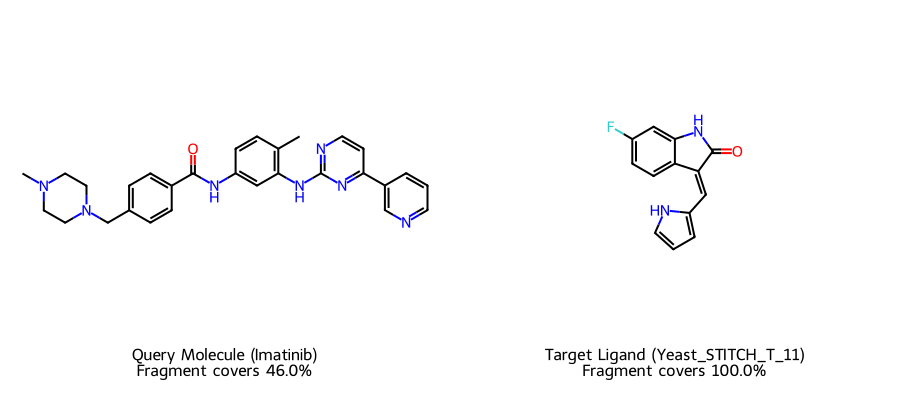

----------------------------------------------------------------------
Target ID:      Yeast_STITCH_T_11 | Polypharm Type: Type 2
Mapped Fragment:*c1cc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)ccc1C
Target Ligand:  C1=CC=C2C(=C1)C=CC(=N2)NC(=O)C3=NSC=C3NCC4=CC=NC=C4
------------------------------
Query (Full) Functional Groups:  carbonyl compound (1), amide (1), tertiary amine (2), pyridine (1), pyrimidine (1)
Target (Full) Functional Groups: carbonyl compound (1), amide (1), pyridine (2)


[16:07:56] SMARTS Parse Error: syntax error while parsing: C=N-OH
[16:07:56] SMARTS Parse Error: Failed parsing SMARTS 'C=N-OH' for input: 'C=N-OH'
[16:07:56] SMARTS Parse Error: syntax error while parsing: N-H
[16:07:56] SMARTS Parse Error: Failed parsing SMARTS 'N-H' for input: 'N-H'
[16:07:56] SMARTS Parse Error: syntax error while parsing: N-R
[16:07:56] SMARTS Parse Error: Failed parsing SMARTS 'N-R' for input: 'N-R'
[16:07:56] SMARTS Parse Error: syntax error while parsing: O-H
[16:07:56] SMARTS Parse Error: Failed parsing SMARTS 'O-H' for input: 'O-H'
[16:07:56] SMARTS Parse Error: syntax error while parsing: C-SH
[16:07:56] SMARTS Parse Error: Failed parsing SMARTS 'C-SH' for input: 'C-SH'
[16:07:56] SMARTS Parse Error: syntax error while parsing: S(=O)(=O)OH
[16:07:56] SMARTS Parse Error: Failed parsing SMARTS 'S(=O)(=O)OH' for input: 'S(=O)(=O)OH'
[16:07:56] SMARTS Parse Error: syntax error while parsing: C=N-OH
[16:07:56] SMARTS Parse Error: Failed parsing SMARTS 'C=N-OH' fo

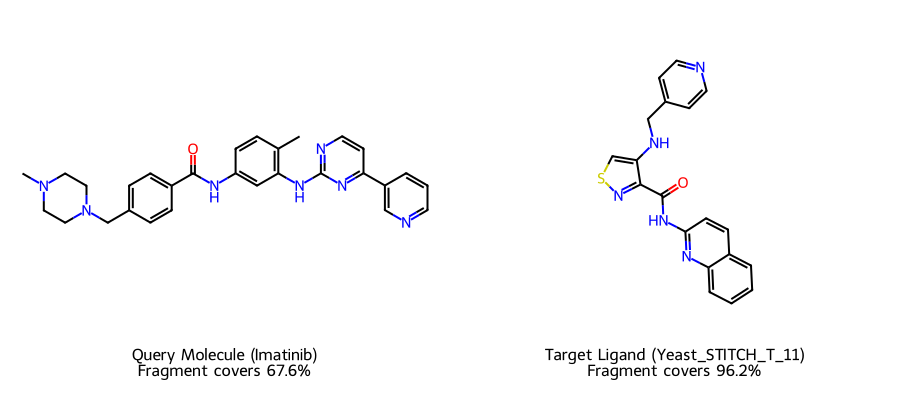

----------------------------------------------------------------------
Target ID:      SMS_T_208 | Polypharm Type: Type 2
Mapped Fragment:*Nc1ccc(C)c(Nc2nccc(-c3cccnc3)n2)c1
Target Ligand:  CC(=O)Nc1ccc(C)c(Nc2nccc(-c3cccnc3)n2)c1
------------------------------
Query (Full) Functional Groups:  carbonyl compound (1), amide (1), tertiary amine (2), pyridine (1), pyrimidine (1)
Target (Full) Functional Groups: carbonyl compound (1), ketone (1), amide (1), pyridine (1), pyrimidine (1)


[16:07:56] SMARTS Parse Error: syntax error while parsing: C=N-OH
[16:07:56] SMARTS Parse Error: Failed parsing SMARTS 'C=N-OH' for input: 'C=N-OH'
[16:07:56] SMARTS Parse Error: syntax error while parsing: N-H
[16:07:56] SMARTS Parse Error: Failed parsing SMARTS 'N-H' for input: 'N-H'
[16:07:56] SMARTS Parse Error: syntax error while parsing: N-R
[16:07:56] SMARTS Parse Error: Failed parsing SMARTS 'N-R' for input: 'N-R'
[16:07:56] SMARTS Parse Error: syntax error while parsing: O-H
[16:07:56] SMARTS Parse Error: Failed parsing SMARTS 'O-H' for input: 'O-H'
[16:07:56] SMARTS Parse Error: syntax error while parsing: C-SH
[16:07:56] SMARTS Parse Error: Failed parsing SMARTS 'C-SH' for input: 'C-SH'
[16:07:56] SMARTS Parse Error: syntax error while parsing: S(=O)(=O)OH
[16:07:56] SMARTS Parse Error: Failed parsing SMARTS 'S(=O)(=O)OH' for input: 'S(=O)(=O)OH'
[16:07:56] SMARTS Parse Error: syntax error while parsing: C=N-OH
[16:07:56] SMARTS Parse Error: Failed parsing SMARTS 'C=N-OH' fo

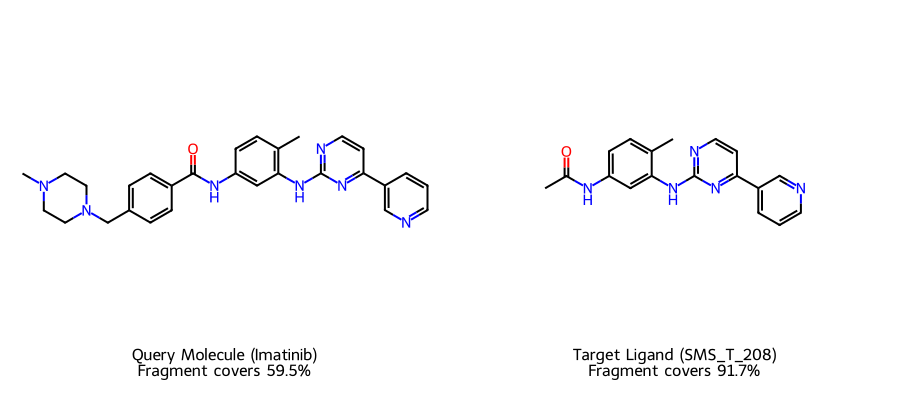

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Draw, Recap
from rdkit.Chem.Draw import rdDepictor
from IPython.display import display

# =====================================================================
# 1. VISUALIZATION STYLING
# =====================================================================
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "axes.linewidth": 1.0,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out"
})

# =====================================================================
# 2. MASTER CHEMICAL GROUPS DICTIONARY
# =====================================================================
MASTER_CHEMICAL_GROUPS = {
    'cation': {'smarts': '[+]'},
    'anion': {'smarts': '[-]'},
    'carbonyl compound': {'smarts': 'C=O'},
    'ketone': {'smarts': 'C(=O)C'},
    'thiocarbonyl compound': {'smarts': 'C=S'},
    'imine': {'smarts': 'C=N'},
    'hydrazone': {'smarts': 'C=N-N'},
    'oxime': {'smarts': 'C=N-OH'},
    'ether': {'smarts': 'C-O-C'},
    'carboxylic acid': {'smarts': 'C(=O)O'},
    'ester': {'smarts': 'C(=O)O-C'},
    'amide': {'smarts': 'C(=O)N'},
    'primary amine': {'smarts': 'N-H'},
    'secondary amine': {'smarts': 'N-R'},
    'tertiary amine': {'smarts': 'N(C)(C)C'},
    'alcohol': {'smarts': 'O-H'},
    'phenol': {'smarts': 'c1ccccc1O'},
    'thiol': {'smarts': 'C-SH'},
    'thioether': {'smarts': 'C-S-C'},
    'disulfide': {'smarts': 'S-S'},
    'sulfonamide': {'smarts': 'S(=O)(=O)N'},
    'sulfone': {'smarts': 'S(=O)(=O)C'},
    'sulfonic acid': {'smarts': 'S(=O)(=O)OH'},
    'phosphate': {'smarts': 'O=P(O)(O)O'},
    'halogen': {'smarts': '[F,Cl,Br,I]'},
    'trifluoromethyl': {'smarts': 'C(F)(F)F'},
    'cyanide / nitrile': {'smarts': 'C#N'},
    'nitro': {'smarts': 'N(=O)=O'},
    'azide': {'smarts': 'N=N=N'},
    'alkyne': {'smarts': 'C#C'},
    'alkene': {'smarts': 'C=C'},
    'furan': {'smarts': 'c1cocc1'},
    'thiophene': {'smarts': 'c1cscc1'},
    'pyrrole': {'smarts': 'c1cc[nH]c1'},
    'pyridine': {'smarts': 'c1ccncc1'},
    'pyrimidine': {'smarts': 'c1cncnc1'},
    'imidazole': {'smarts': 'c1c[nH]cn1'},
    'pyrazole': {'smarts': 'c1c[nH]nc1'},
}

def identify_functional_groups(mol):
    detected = []
    for name, properties in MASTER_CHEMICAL_GROUPS.items():
        pattern = Chem.MolFromSmarts(properties['smarts'])
        if pattern is None:
            continue 
            
        matches = mol.GetSubstructMatches(pattern)
        if matches:
            detected.append(f"{name} ({len(matches)})")
            
    return ", ".join(detected) if detected else "None"

# =====================================================================
# 3. POLYPHARMACOLOGY TYPE ANALYSIS
# =====================================================================
def get_mcs_smile(query_mol, target_mol):
    from rdkit.Chem import rdFMCS
    if query_mol is None or target_mol is None: return None
    mcs = rdFMCS.FindMCS([query_mol, target_mol], timeout=3)
    if mcs is None or not mcs.smartsString: return None
    return Chem.MolToSmiles(Chem.MolFromSmarts(mcs.smartsString), isomericSmiles=True)

def perform_type_analysis(df, parent_smiles):
    print("--- Running Type Analysis ---")
    unique_queries = set(df['query_frag_smile'].unique())
    unique_target_count = df['Target_ID'].nunique()
    
    molecule = Chem.MolFromSmiles(parent_smiles)
    hierarchy = Recap.RecapDecompose(molecule)
    first_level_keys = sorted(hierarchy.children.keys())

    if len(first_level_keys) < 2:
        df['Polypharmacology_Type'] = "Type 1" if unique_target_count == 1 else "Type 2"
        return df

    query_frag = Chem.MolToSmiles(hierarchy.children[first_level_keys[0]].mol, isomericSmiles=True)
    query_frag_mol = Chem.MolFromSmiles(query_frag)
    s1map_list = [query_frag]
    s2map_list = []

    for i in range(1, len(first_level_keys)):
        target_frag = Chem.MolToSmiles(hierarchy.children[first_level_keys[i]].mol, isomericSmiles=True)
        target_frag_mol = Chem.MolFromSmiles(target_frag)
        mcs_smile = get_mcs_smile(query_frag_mol, target_frag_mol)

        if mcs_smile == Chem.MolToSmiles(query_frag_mol, isomericSmiles=True):
            s1map_list.append(target_frag)
        else:
            s2map_list.append(target_frag)

    s1_match = s2_match = False
    for query in unique_queries:
        for s1_frag in s1map_list:
            if get_mcs_smile(Chem.MolFromSmiles(s1_frag), Chem.MolFromSmiles(query)) == query: s1_match = True
        for s2_frag in s2map_list:
            if get_mcs_smile(Chem.MolFromSmiles(s2_frag), Chem.MolFromSmiles(query)) == query: s2_match = True

    query_count = len(unique_queries)
    if query_count < 1: result = "Type 5"
    elif query_count == 1: result = "Type 1" if unique_target_count == 1 else "Type 2"
    else:
        if not s1_match and not s2_match: result = "Type 1" if unique_target_count == 1 else "Type 2"
        else: result = "Type 3" if unique_target_count == 1 else "Type 4"

    df['Polypharmacology_Type'] = result
    return df

# =====================================================================
# 4. MAIN PIPELINE (Filter -> Analyze -> Visualize)
# =====================================================================
def analyze_and_visualize(csv_path, parent_smiles):
    print(f"Loading data from {csv_path}...")
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: {csv_path} not found.")
        return

    # 1. APPLY FILTERS
    df = df[df['query_smile_atom_count'] >= 10]
    df = df[df["Query_Percentage"] >= 25]
    df = df[df["Target_Percentage"] >= 75]
    df = df[df["Target_Percentage"] <= 100.0]

    if len(df) == 0:
        print("⚠️ No matches survived the filtering thresholds.")
        return

    # 2. RUN TYPE ANALYSIS
    df = perform_type_analysis(df, parent_smiles)
    
    # 3. DENSITY PLOTS
    unique_queries = df['query_smile_atom_count'].nunique()
    if unique_queries > 1 and len(df) > 1:
        print("Drawing 1x3 Density Grid...")
        fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
        sns.kdeplot(data=df, x='query_smile_atom_count', fill=True, ax=axes[0], color='blue', warn_singular=False)
        axes[0].set_title('Query Atom Count Density')
        sns.kdeplot(data=df, x='Query_Percentage', fill=True, ax=axes[1], color='green', warn_singular=False)
        axes[1].set_title('Query Coverage Density (%)')
        sns.kdeplot(data=df, x='Target_Percentage', fill=True, ax=axes[2], color='red', warn_singular=False)
        axes[2].set_title('Target Coverage Density (%)')
        plt.tight_layout()
        plt.show()

    # 4. HIGHLIGHT MAPPED FRAGMENTS IN FULL MOLECULES
    print("\nHighlighting shared fragments within the FULL Parent Molecules...")
    rdDepictor.SetPreferCoordGen(True)
    
    # Custom aesthetic settings to match user's screenshot
    dopts = Draw.rdMolDraw2D.MolDrawOptions()
    dopts.continuousHighlight = True               # Creates the solid block highlight
    dopts.setHighlightColour((0.9, 0.4, 0.7, 0.5)) # Custom Pink/Magenta Color
    
    vis_df = df.drop_duplicates(subset=['Target_ID', 'query_frag_smile']).head(3)
    parent_mol = Chem.MolFromSmiles(parent_smiles)
    
    for i, row in vis_df.iterrows():
        print("-" * 70)
        print(f"Target ID:      {row.get('Target_ID', 'N/A')} | Polypharm Type: {row['Polypharmacology_Type']}")
        print(f"Mapped Fragment:{row['query_frag_smile']}")
        print(f"Target Ligand:  {row['original_target_smile']}")
        print("-" * 30)
        
        t_mol = Chem.MolFromSmiles(row['original_target_smile'])
        frag_mol = Chem.MolFromSmiles(row['query_frag_smile'])

        if not parent_mol or not t_mol or not frag_mol:
            continue

        # Get Atom matches for the fragment INSIDE the full molecules
        match_parent = parent_mol.GetSubstructMatch(frag_mol)
        match_target = t_mol.GetSubstructMatch(frag_mol)
        
        print(f"Query (Full) Functional Groups:  {identify_functional_groups(parent_mol)}")
        print(f"Target (Full) Functional Groups: {identify_functional_groups(t_mol)}")

        img = Draw.MolsToGridImage(
            [parent_mol, t_mol],
            highlightAtomLists=[list(match_parent), list(match_target)],
            legends=[f"Query Molecule (Imatinib)\nFragment covers {row['Query_Percentage']:.1f}%", 
                     f"Target Ligand ({row['Target_ID']})\nFragment covers {row['Target_Percentage']:.1f}%"],
            molsPerRow=2,
            subImgSize=(450, 400),
            useSVG=True,
            drawOptions=dopts
        )
        display(img)

if __name__ == "__main__":
    IMATINIB_SMILES = "CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C)NC4=NC=CC(=N4)C5=CN=CC=C5"
    analyze_and_visualize("Imatinib_Mapped_Targets.csv", IMATINIB_SMILES)

Loading data from Imatinib_Mapped_Targets.csv...
--- Running Type Analysis ---

Highlighting shared fragments within the FULL Parent Molecules...
----------------------------------------------------------------------
Target ID:      Yeast_STITCH_T_11 | Polypharm Type: Type 2
Mapped Fragment:*C(=O)c1ccc(CN2CCN(C)CC2)cc1
Target Ligand:  C1=CNC(=C1)C=C2C3=C(C=C(C=C3)F)NC2=O
------------------------------
Query (Full) Functional Groups:  carbonyl compound (1), amide (1), tertiary amine (2), pyridine (1), pyrimidine (1)
Target (Full) Functional Groups: carbonyl compound (1), ketone (1), amide (1), halogen (1), alkene (1), pyrrole (1)


[16:10:06] SMARTS Parse Error: syntax error while parsing: C=N-OH
[16:10:06] SMARTS Parse Error: Failed parsing SMARTS 'C=N-OH' for input: 'C=N-OH'
[16:10:06] SMARTS Parse Error: syntax error while parsing: N-H
[16:10:06] SMARTS Parse Error: Failed parsing SMARTS 'N-H' for input: 'N-H'
[16:10:06] SMARTS Parse Error: syntax error while parsing: N-R
[16:10:06] SMARTS Parse Error: Failed parsing SMARTS 'N-R' for input: 'N-R'
[16:10:06] SMARTS Parse Error: syntax error while parsing: O-H
[16:10:06] SMARTS Parse Error: Failed parsing SMARTS 'O-H' for input: 'O-H'
[16:10:06] SMARTS Parse Error: syntax error while parsing: C-SH
[16:10:06] SMARTS Parse Error: Failed parsing SMARTS 'C-SH' for input: 'C-SH'
[16:10:06] SMARTS Parse Error: syntax error while parsing: S(=O)(=O)OH
[16:10:06] SMARTS Parse Error: Failed parsing SMARTS 'S(=O)(=O)OH' for input: 'S(=O)(=O)OH'
[16:10:06] SMARTS Parse Error: syntax error while parsing: C=N-OH
[16:10:06] SMARTS Parse Error: Failed parsing SMARTS 'C=N-OH' fo

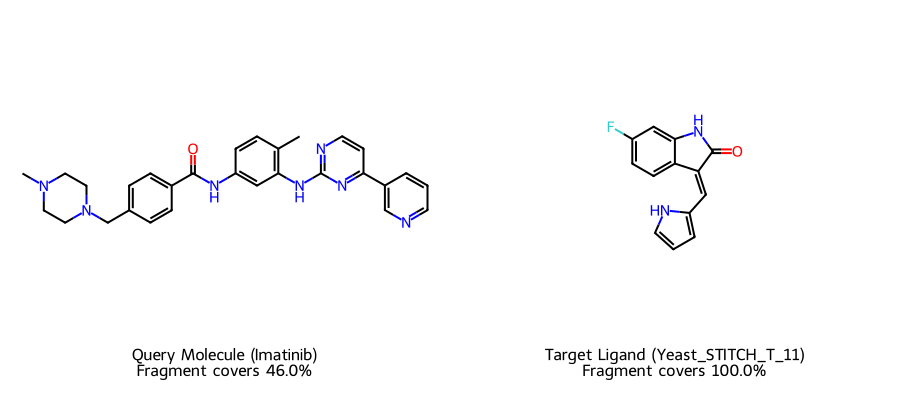

----------------------------------------------------------------------
Target ID:      Yeast_STITCH_T_11 | Polypharm Type: Type 2
Mapped Fragment:*c1cc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)ccc1C
Target Ligand:  C1=CC=C2C(=C1)C=CC(=N2)NC(=O)C3=NSC=C3NCC4=CC=NC=C4
------------------------------
Query (Full) Functional Groups:  carbonyl compound (1), amide (1), tertiary amine (2), pyridine (1), pyrimidine (1)
Target (Full) Functional Groups: carbonyl compound (1), amide (1), pyridine (2)


[16:10:06] SMARTS Parse Error: syntax error while parsing: C=N-OH
[16:10:06] SMARTS Parse Error: Failed parsing SMARTS 'C=N-OH' for input: 'C=N-OH'
[16:10:06] SMARTS Parse Error: syntax error while parsing: N-H
[16:10:06] SMARTS Parse Error: Failed parsing SMARTS 'N-H' for input: 'N-H'
[16:10:06] SMARTS Parse Error: syntax error while parsing: N-R
[16:10:06] SMARTS Parse Error: Failed parsing SMARTS 'N-R' for input: 'N-R'
[16:10:06] SMARTS Parse Error: syntax error while parsing: O-H
[16:10:06] SMARTS Parse Error: Failed parsing SMARTS 'O-H' for input: 'O-H'
[16:10:06] SMARTS Parse Error: syntax error while parsing: C-SH
[16:10:06] SMARTS Parse Error: Failed parsing SMARTS 'C-SH' for input: 'C-SH'
[16:10:06] SMARTS Parse Error: syntax error while parsing: S(=O)(=O)OH
[16:10:06] SMARTS Parse Error: Failed parsing SMARTS 'S(=O)(=O)OH' for input: 'S(=O)(=O)OH'
[16:10:06] SMARTS Parse Error: syntax error while parsing: C=N-OH
[16:10:06] SMARTS Parse Error: Failed parsing SMARTS 'C=N-OH' fo

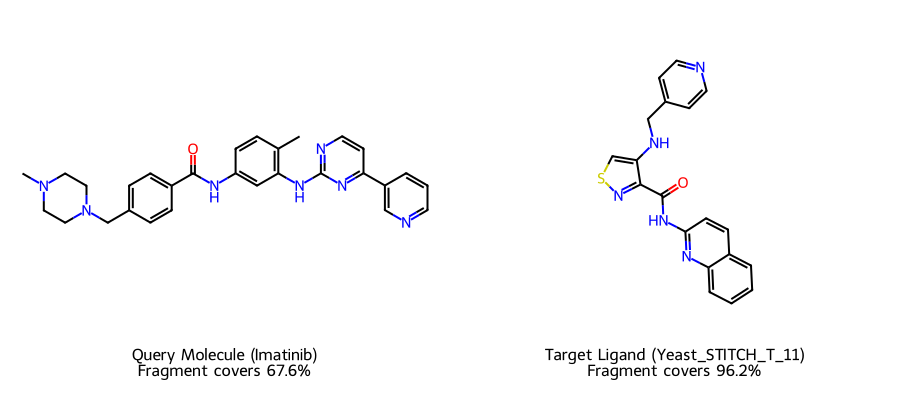

----------------------------------------------------------------------
Target ID:      SMS_T_208 | Polypharm Type: Type 2
Mapped Fragment:*Nc1ccc(C)c(Nc2nccc(-c3cccnc3)n2)c1
Target Ligand:  CC(=O)Nc1ccc(C)c(Nc2nccc(-c3cccnc3)n2)c1
------------------------------
Query (Full) Functional Groups:  carbonyl compound (1), amide (1), tertiary amine (2), pyridine (1), pyrimidine (1)
Target (Full) Functional Groups: carbonyl compound (1), ketone (1), amide (1), pyridine (1), pyrimidine (1)


[16:10:06] SMARTS Parse Error: syntax error while parsing: C=N-OH
[16:10:06] SMARTS Parse Error: Failed parsing SMARTS 'C=N-OH' for input: 'C=N-OH'
[16:10:06] SMARTS Parse Error: syntax error while parsing: N-H
[16:10:06] SMARTS Parse Error: Failed parsing SMARTS 'N-H' for input: 'N-H'
[16:10:06] SMARTS Parse Error: syntax error while parsing: N-R
[16:10:06] SMARTS Parse Error: Failed parsing SMARTS 'N-R' for input: 'N-R'
[16:10:06] SMARTS Parse Error: syntax error while parsing: O-H
[16:10:06] SMARTS Parse Error: Failed parsing SMARTS 'O-H' for input: 'O-H'
[16:10:06] SMARTS Parse Error: syntax error while parsing: C-SH
[16:10:06] SMARTS Parse Error: Failed parsing SMARTS 'C-SH' for input: 'C-SH'
[16:10:06] SMARTS Parse Error: syntax error while parsing: S(=O)(=O)OH
[16:10:06] SMARTS Parse Error: Failed parsing SMARTS 'S(=O)(=O)OH' for input: 'S(=O)(=O)OH'
[16:10:06] SMARTS Parse Error: syntax error while parsing: C=N-OH
[16:10:06] SMARTS Parse Error: Failed parsing SMARTS 'C=N-OH' fo

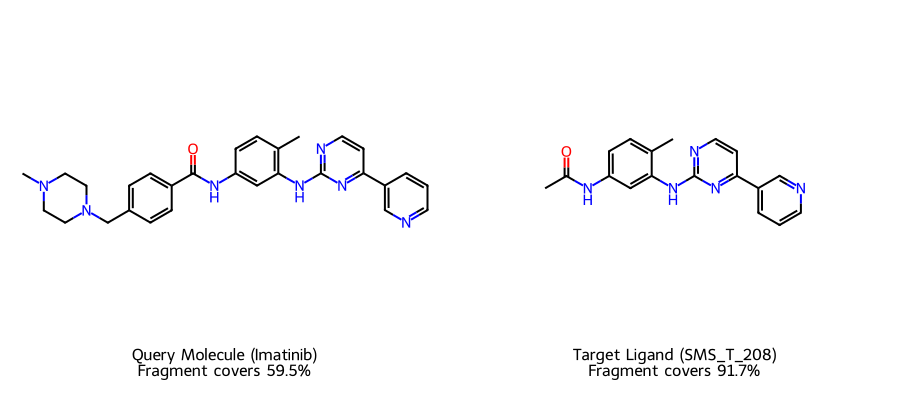

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Draw, Recap
from rdkit.Chem.Draw import rdDepictor
from IPython.display import display

# =====================================================================
# 1. VISUALIZATION STYLING
# =====================================================================
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "axes.linewidth": 1.0,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out"
})

# =====================================================================
# 2. MASTER CHEMICAL GROUPS DICTIONARY
# =====================================================================
MASTER_CHEMICAL_GROUPS = {
    'cation': {'smarts': '[+]'},
    'anion': {'smarts': '[-]'},
    'carbonyl compound': {'smarts': 'C=O'},
    'ketone': {'smarts': 'C(=O)C'},
    'thiocarbonyl compound': {'smarts': 'C=S'},
    'imine': {'smarts': 'C=N'},
    'hydrazone': {'smarts': 'C=N-N'},
    'oxime': {'smarts': 'C=N-OH'},
    'ether': {'smarts': 'C-O-C'},
    'carboxylic acid': {'smarts': 'C(=O)O'},
    'ester': {'smarts': 'C(=O)O-C'},
    'amide': {'smarts': 'C(=O)N'},
    'primary amine': {'smarts': 'N-H'},
    'secondary amine': {'smarts': 'N-R'},
    'tertiary amine': {'smarts': 'N(C)(C)C'},
    'alcohol': {'smarts': 'O-H'},
    'phenol': {'smarts': 'c1ccccc1O'},
    'thiol': {'smarts': 'C-SH'},
    'thioether': {'smarts': 'C-S-C'},
    'disulfide': {'smarts': 'S-S'},
    'sulfonamide': {'smarts': 'S(=O)(=O)N'},
    'sulfone': {'smarts': 'S(=O)(=O)C'},
    'sulfonic acid': {'smarts': 'S(=O)(=O)OH'},
    'phosphate': {'smarts': 'O=P(O)(O)O'},
    'halogen': {'smarts': '[F,Cl,Br,I]'},
    'trifluoromethyl': {'smarts': 'C(F)(F)F'},
    'cyanide / nitrile': {'smarts': 'C#N'},
    'nitro': {'smarts': 'N(=O)=O'},
    'azide': {'smarts': 'N=N=N'},
    'alkyne': {'smarts': 'C#C'},
    'alkene': {'smarts': 'C=C'},
    'furan': {'smarts': 'c1cocc1'},
    'thiophene': {'smarts': 'c1cscc1'},
    'pyrrole': {'smarts': 'c1cc[nH]c1'},
    'pyridine': {'smarts': 'c1ccncc1'},
    'pyrimidine': {'smarts': 'c1cncnc1'},
    'imidazole': {'smarts': 'c1c[nH]cn1'},
    'pyrazole': {'smarts': 'c1c[nH]nc1'},
}

def identify_functional_groups(mol):
    detected = []
    for name, properties in MASTER_CHEMICAL_GROUPS.items():
        pattern = Chem.MolFromSmarts(properties['smarts'])
        if pattern is None:
            continue 
            
        matches = mol.GetSubstructMatches(pattern)
        if matches:
            detected.append(f"{name} ({len(matches)})")
            
    return ", ".join(detected) if detected else "None"

# =====================================================================
# 3. POLYPHARMACOLOGY TYPE ANALYSIS
# =====================================================================
def get_mcs_smile(query_mol, target_mol):
    from rdkit.Chem import rdFMCS
    if query_mol is None or target_mol is None: return None
    mcs = rdFMCS.FindMCS([query_mol, target_mol], timeout=3)
    if mcs is None or not mcs.smartsString: return None
    return Chem.MolToSmiles(Chem.MolFromSmarts(mcs.smartsString), isomericSmiles=True)

def perform_type_analysis(df, parent_smiles):
    print("--- Running Type Analysis ---")
    unique_queries = set(df['query_frag_smile'].unique())
    unique_target_count = df['Target_ID'].nunique()
    
    molecule = Chem.MolFromSmiles(parent_smiles)
    hierarchy = Recap.RecapDecompose(molecule)
    first_level_keys = sorted(hierarchy.children.keys())

    if len(first_level_keys) < 2:
        df['Polypharmacology_Type'] = "Type 1" if unique_target_count == 1 else "Type 2"
        return df

    query_frag = Chem.MolToSmiles(hierarchy.children[first_level_keys[0]].mol, isomericSmiles=True)
    query_frag_mol = Chem.MolFromSmiles(query_frag)
    s1map_list = [query_frag]
    s2map_list = []

    for i in range(1, len(first_level_keys)):
        target_frag = Chem.MolToSmiles(hierarchy.children[first_level_keys[i]].mol, isomericSmiles=True)
        target_frag_mol = Chem.MolFromSmiles(target_frag)
        mcs_smile = get_mcs_smile(query_frag_mol, target_frag_mol)

        if mcs_smile == Chem.MolToSmiles(query_frag_mol, isomericSmiles=True):
            s1map_list.append(target_frag)
        else:
            s2map_list.append(target_frag)

    s1_match = s2_match = False
    for query in unique_queries:
        for s1_frag in s1map_list:
            if get_mcs_smile(Chem.MolFromSmiles(s1_frag), Chem.MolFromSmiles(query)) == query: s1_match = True
        for s2_frag in s2map_list:
            if get_mcs_smile(Chem.MolFromSmiles(s2_frag), Chem.MolFromSmiles(query)) == query: s2_match = True

    query_count = len(unique_queries)
    if query_count < 1: result = "Type 5"
    elif query_count == 1: result = "Type 1" if unique_target_count == 1 else "Type 2"
    else:
        if not s1_match and not s2_match: result = "Type 1" if unique_target_count == 1 else "Type 2"
        else: result = "Type 3" if unique_target_count == 1 else "Type 4"

    df['Polypharmacology_Type'] = result
    return df

# =====================================================================
# 4. MAIN PIPELINE (Filter -> Analyze -> Visualize)
# =====================================================================
def analyze_and_visualize(csv_path, parent_smiles):
    print(f"Loading data from {csv_path}...")
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: {csv_path} not found.")
        return

    # 1. APPLY FILTERS
    df = df[df['query_smile_atom_count'] >= 10]
    df = df[df["Query_Percentage"] >= 25]
    df = df[df["Target_Percentage"] >= 75]
    df = df[df["Target_Percentage"] <= 100.0]

    if len(df) == 0:
        print("⚠️ No matches survived the filtering thresholds.")
        return

    # 2. RUN TYPE ANALYSIS
    df = perform_type_analysis(df, parent_smiles)
    
    # 3. DENSITY PLOTS
    unique_queries = df['query_smile_atom_count'].nunique()
    if unique_queries > 1 and len(df) > 1:
        print("Drawing 1x3 Density Grid...")
        fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
        sns.kdeplot(data=df, x='query_smile_atom_count', fill=True, ax=axes[0], color='blue', warn_singular=False)
        axes[0].set_title('Query Atom Count Density')
        sns.kdeplot(data=df, x='Query_Percentage', fill=True, ax=axes[1], color='green', warn_singular=False)
        axes[1].set_title('Query Coverage Density (%)')
        sns.kdeplot(data=df, x='Target_Percentage', fill=True, ax=axes[2], color='red', warn_singular=False)
        axes[2].set_title('Target Coverage Density (%)')
        plt.tight_layout()
        plt.show()

    # 4. HIGHLIGHT MAPPED FRAGMENTS IN FULL MOLECULES
    print("\nHighlighting shared fragments within the FULL Parent Molecules...")
    rdDepictor.SetPreferCoordGen(True)
    
    # Custom aesthetic settings to match user's screenshot
    dopts = Draw.rdMolDraw2D.MolDrawOptions()
    dopts.continuousHighlight = True               # Creates the solid block highlight
    dopts.setHighlightColour((0.9, 0.4, 0.7, 0.5)) # Custom Pink/Magenta Color
    
    vis_df = df.drop_duplicates(subset=['Target_ID', 'query_frag_smile']).head(3)
    parent_mol = Chem.MolFromSmiles(parent_smiles)
    
    for i, row in vis_df.iterrows():
        print("-" * 70)
        print(f"Target ID:      {row.get('Target_ID', 'N/A')} | Polypharm Type: {row['Polypharmacology_Type']}")
        print(f"Mapped Fragment:{row['query_frag_smile']}")
        print(f"Target Ligand:  {row['original_target_smile']}")
        print("-" * 30)
        
        t_mol = Chem.MolFromSmiles(row['original_target_smile'])
        frag_mol = Chem.MolFromSmiles(row['query_frag_smile'])

        if not parent_mol or not t_mol or not frag_mol:
            continue

        # Get Atom matches for the fragment INSIDE the full molecules
        match_parent = parent_mol.GetSubstructMatch(frag_mol)
        match_target = t_mol.GetSubstructMatch(frag_mol)
        
        print(f"Query (Full) Functional Groups:  {identify_functional_groups(parent_mol)}")
        print(f"Target (Full) Functional Groups: {identify_functional_groups(t_mol)}")

        img = Draw.MolsToGridImage(
            [parent_mol, t_mol],
            highlightAtomLists=[list(match_parent), list(match_target)],
            legends=[f"Query Molecule (Imatinib)\nFragment covers {row['Query_Percentage']:.1f}%", 
                     f"Target Ligand ({row['Target_ID']})\nFragment covers {row['Target_Percentage']:.1f}%"],
            molsPerRow=2,
            subImgSize=(450, 400),
            useSVG=True,
            drawOptions=dopts
        )
        display(img)

if __name__ == "__main__":
    IMATINIB_SMILES = "CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C)NC4=NC=CC(=N4)C5=CN=CC=C5"
    analyze_and_visualize("Imatinib_Mapped_Targets.csv", IMATINIB_SMILES)

Loading data from Imatinib_Mapped_Targets.csv...
--- Running Type Analysis ---

Highlighting shared fragments within the FULL Parent Molecules...
🎯 Target Protein:       Yeast_STITCH_T_11
🧬 Polypharmacy Class:   Type 2 (Monovalent Multitarget)
------------------------------------------------------------------------------------------
🔗 Shared Fragment:      *C(=O)c1ccc(CN2CCN(C)CC2)cc1
⬅️ From Query Molecule:  CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C)NC4=NC=CC(=N4)C5=CN=CC=C5
➡️ Maps to Target Ligand: C1=CNC(=C1)C=C2C3=C(C=C(C=C3)F)NC2=O (ID: ST_Y_10619)
Query (Full) Functional Groups:  carbonyl compound (1), amide (1), secondary amine (2), tertiary amine (2), pyridine (1), pyrimidine (1)
Target (Full) Functional Groups: carbonyl compound (1), ketone (1), amide (1), secondary amine (1), halogen (1), alkene (1), pyrrole (1)



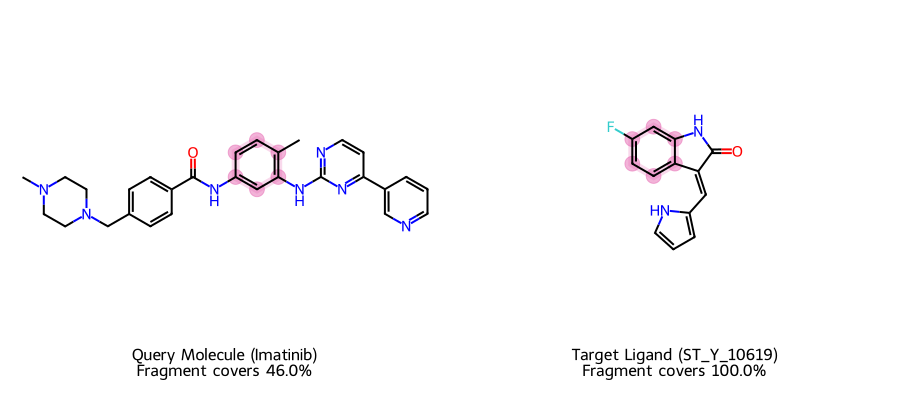

🎯 Target Protein:       Yeast_STITCH_T_11
🧬 Polypharmacy Class:   Type 2 (Monovalent Multitarget)
------------------------------------------------------------------------------------------
🔗 Shared Fragment:      *c1cc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)ccc1C
⬅️ From Query Molecule:  CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C)NC4=NC=CC(=N4)C5=CN=CC=C5
➡️ Maps to Target Ligand: C1=CC=C2C(=C1)C=CC(=N2)NC(=O)C3=NSC=C3NCC4=CC=NC=C4 (ID: ST_Y_4967)
Query (Full) Functional Groups:  carbonyl compound (1), amide (1), secondary amine (2), tertiary amine (2), pyridine (1), pyrimidine (1)
Target (Full) Functional Groups: carbonyl compound (1), amide (1), secondary amine (2), pyridine (2)



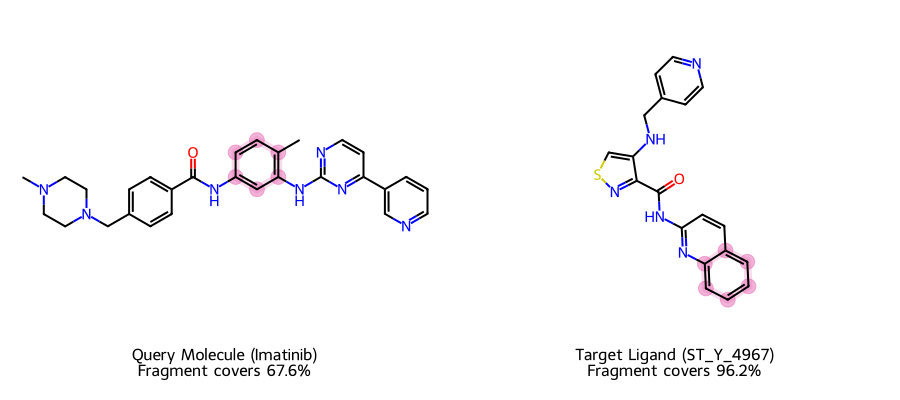

🎯 Target Protein:       SMS_T_208
🧬 Polypharmacy Class:   Type 2 (Monovalent Multitarget)
------------------------------------------------------------------------------------------
🔗 Shared Fragment:      *Nc1ccc(C)c(Nc2nccc(-c3cccnc3)n2)c1
⬅️ From Query Molecule:  CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C)NC4=NC=CC(=N4)C5=CN=CC=C5
➡️ Maps to Target Ligand: CC(=O)Nc1ccc(C)c(Nc2nccc(-c3cccnc3)n2)c1 (ID: SMS_939791)
Query (Full) Functional Groups:  carbonyl compound (1), amide (1), secondary amine (2), tertiary amine (2), pyridine (1), pyrimidine (1)
Target (Full) Functional Groups: carbonyl compound (1), ketone (1), amide (1), secondary amine (2), pyridine (1), pyrimidine (1)



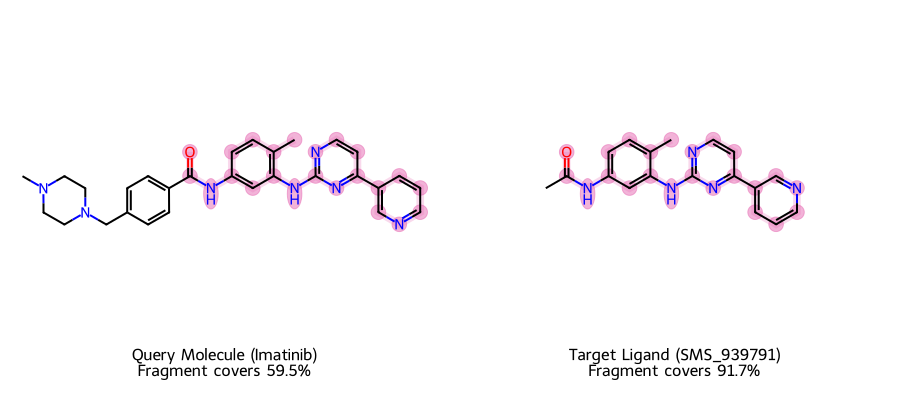

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Draw, Recap, rdFMCS
from rdkit.Chem.Draw import rdDepictor
from rdkit import RDLogger
from IPython.display import display

# =====================================================================
# 1. VISUALIZATION STYLING & CLEANUP
# =====================================================================
RDLogger.DisableLog('rdApp.*') # Mutes strict RDKit SMARTS warnings

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "axes.linewidth": 1.0,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out"
})

# =====================================================================
# 2. MASTER CHEMICAL GROUPS DICTIONARY
# =====================================================================
MASTER_CHEMICAL_GROUPS = {
    'cation': {'smarts': '[+]'},
    'anion': {'smarts': '[-]'},
    'carbonyl compound': {'smarts': 'C=O'},
    'ketone': {'smarts': 'C(=O)C'},
    'thiocarbonyl compound': {'smarts': 'C=S'},
    'imine': {'smarts': 'C=N'},
    'hydrazone': {'smarts': 'C=N-N'},
    'oxime': {'smarts': 'C=N-[OH]'},
    'ether': {'smarts': 'C-O-C'},
    'carboxylic acid': {'smarts': 'C(=O)[OH]'},
    'ester': {'smarts': 'C(=O)O-C'},
    'amide': {'smarts': 'C(=O)N'},
    'primary amine': {'smarts': '[NX3H2]'},
    'secondary amine': {'smarts': '[NX3H1]'},
    'tertiary amine': {'smarts': '[NX3H0]'},
    'alcohol': {'smarts': '[OX2H]'},
    'phenol': {'smarts': 'c1ccccc1[OH]'},
    'thiol': {'smarts': '[SX2H]'},
    'thioether': {'smarts': 'C-S-C'},
    'disulfide': {'smarts': 'S-S'},
    'sulfonamide': {'smarts': 'S(=O)(=O)N'},
    'sulfone': {'smarts': 'S(=O)(=O)C'},
    'sulfonic acid': {'smarts': 'S(=O)(=O)[OH]'},
    'phosphate': {'smarts': 'O=P(O)(O)O'},
    'halogen': {'smarts': '[F,Cl,Br,I]'},
    'trifluoromethyl': {'smarts': 'C(F)(F)F'},
    'cyanide / nitrile': {'smarts': 'C#N'},
    'nitro': {'smarts': 'N(=O)=O'},
    'azide': {'smarts': 'N=N=N'},
    'alkyne': {'smarts': 'C#C'},
    'alkene': {'smarts': 'C=C'},
    'furan': {'smarts': 'c1cocc1'},
    'thiophene': {'smarts': 'c1cscc1'},
    'pyrrole': {'smarts': 'c1cc[nH]c1'},
    'pyridine': {'smarts': 'c1ccncc1'},
    'pyrimidine': {'smarts': 'c1cncnc1'},
    'imidazole': {'smarts': 'c1c[nH]cn1'},
    'pyrazole': {'smarts': 'c1c[nH]nc1'},
}

def identify_functional_groups(mol):
    detected = []
    for name, properties in MASTER_CHEMICAL_GROUPS.items():
        pattern = Chem.MolFromSmarts(properties['smarts'])
        if pattern is None: continue 
        matches = mol.GetSubstructMatches(pattern)
        if matches: detected.append(f"{name} ({len(matches)})")
    return ", ".join(detected) if detected else "None"

# =====================================================================
# 3. POLYPHARMACOLOGY TYPE ANALYSIS & NOMENCLATURE
# =====================================================================
TYPE_NAMES = {
    "Type 1": "Type 1 (Monovalent Monotarget)",
    "Type 2": "Type 2 (Monovalent Multitarget)",
    "Type 3": "Type 3 (Multivalent Monotarget)",
    "Type 4": "Type 4 (Multivalent Multitarget)",
    "Type 5": "Type 5 (Unclassified)"
}

def get_mcs_smile(query_mol, target_mol):
    if query_mol is None or target_mol is None: return None
    mcs = rdFMCS.FindMCS([query_mol, target_mol], timeout=3)
    if mcs is None or not mcs.smartsString: return None
    return Chem.MolToSmiles(Chem.MolFromSmarts(mcs.smartsString), isomericSmiles=True)

def perform_type_analysis(df, parent_smiles):
    print("--- Running Type Analysis ---")
    unique_queries = set(df['query_frag_smile'].unique())
    unique_target_count = df['Target_ID'].nunique()
    
    molecule = Chem.MolFromSmiles(parent_smiles)
    hierarchy = Recap.RecapDecompose(molecule)
    first_level_keys = sorted(hierarchy.children.keys())

    if len(first_level_keys) < 2:
        df['Polypharmacology_Type'] = "Type 1" if unique_target_count == 1 else "Type 2"
        return df

    query_frag = Chem.MolToSmiles(hierarchy.children[first_level_keys[0]].mol, isomericSmiles=True)
    query_frag_mol = Chem.MolFromSmiles(query_frag)
    s1map_list = [query_frag]
    s2map_list = []

    for i in range(1, len(first_level_keys)):
        target_frag = Chem.MolToSmiles(hierarchy.children[first_level_keys[i]].mol, isomericSmiles=True)
        target_frag_mol = Chem.MolFromSmiles(target_frag)
        mcs_smile = get_mcs_smile(query_frag_mol, target_frag_mol)

        if mcs_smile == Chem.MolToSmiles(query_frag_mol, isomericSmiles=True):
            s1map_list.append(target_frag)
        else:
            s2map_list.append(target_frag)

    s1_match = s2_match = False
    for query in unique_queries:
        for s1_frag in s1map_list:
            if get_mcs_smile(Chem.MolFromSmiles(s1_frag), Chem.MolFromSmiles(query)) == query: s1_match = True
        for s2_frag in s2map_list:
            if get_mcs_smile(Chem.MolFromSmiles(s2_frag), Chem.MolFromSmiles(query)) == query: s2_match = True

    query_count = len(unique_queries)
    if query_count < 1: result = "Type 5"
    elif query_count == 1: result = "Type 1" if unique_target_count == 1 else "Type 2"
    else:
        if not s1_match and not s2_match: result = "Type 1" if unique_target_count == 1 else "Type 2"
        else: result = "Type 3" if unique_target_count == 1 else "Type 4"

    df['Polypharmacology_Type'] = result
    return df

# =====================================================================
# 4. MAIN PIPELINE (Filter -> Analyze -> Visualize)
# =====================================================================
def analyze_and_visualize(csv_path, parent_smiles):
    print(f"Loading data from {csv_path}...")
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: {csv_path} not found.")
        return

    # 1. APPLY FILTERS
    df = df[df['query_smile_atom_count'] >= 10]
    df = df[df["Query_Percentage"] >= 25]
    df = df[df["Target_Percentage"] >= 75]
    df = df[df["Target_Percentage"] <= 100.0]

    if len(df) == 0:
        print("⚠️ No matches survived the filtering thresholds.")
        return

    # 2. RUN TYPE ANALYSIS
    df = perform_type_analysis(df, parent_smiles)
    
    # 3. DENSITY PLOTS
    unique_queries = df['query_smile_atom_count'].nunique()
    if unique_queries > 1 and len(df) > 1:
        print("Drawing 1x3 Density Grid...")
        fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
        sns.kdeplot(data=df, x='query_smile_atom_count', fill=True, ax=axes[0], color='blue', warn_singular=False)
        axes[0].set_title('Query Atom Count Density')
        sns.kdeplot(data=df, x='Query_Percentage', fill=True, ax=axes[1], color='green', warn_singular=False)
        axes[1].set_title('Query Coverage Density (%)')
        sns.kdeplot(data=df, x='Target_Percentage', fill=True, ax=axes[2], color='red', warn_singular=False)
        axes[2].set_title('Target Coverage Density (%)')
        plt.tight_layout()
        plt.show()

    # 4. HIGHLIGHT MAPPED FRAGMENTS IN FULL MOLECULES
    print("\nHighlighting shared fragments within the FULL Parent Molecules...")
    rdDepictor.SetPreferCoordGen(True)
    
    # Custom aesthetic settings 
    dopts = Draw.rdMolDraw2D.MolDrawOptions()
    dopts.continuousHighlight = True               
    dopts.setHighlightColour((0.9, 0.4, 0.7, 0.5)) 
    
    # Get Top 3 unique targets for display
    vis_df = df.drop_duplicates(subset=['Target_ID', 'query_frag_smile']).head(3)
    parent_mol = Chem.MolFromSmiles(parent_smiles)
    
    for i, row in vis_df.iterrows():
        raw_type = row['Polypharmacology_Type']
        descriptive_type = TYPE_NAMES.get(raw_type, raw_type)
        
        # EXPLICIT DETAILED PRINTOUTS
        print("=" * 90)
        print(f"🎯 Target Protein:       {row.get('Target_ID', 'Unknown')}")
        print(f"🧬 Polypharmacy Class:   {descriptive_type}")
        print("-" * 90)
        print(f"🔗 Shared Fragment:      {row['query_frag_smile']}")
        print(f"⬅️ From Query Molecule:  {parent_smiles}")
        print(f"➡️ Maps to Target Ligand: {row['original_target_smile']} (ID: {row.get('Database_ID', 'Unknown')})")
        print("=" * 90)
        
        t_mol = Chem.MolFromSmiles(row['original_target_smile'])

        if not parent_mol or not t_mol:
            continue

        # FIX: Find the exact shared structure between the two FULL molecules directly
        # This bypasses the dummy atom (*) issue completely!
        mcs = rdFMCS.FindMCS([parent_mol, t_mol], timeout=5, ringMatchesRingOnly=True, completeRingsOnly=True)
        
        if mcs and mcs.smartsString:
            mcs_mol = Chem.MolFromSmarts(mcs.smartsString)
            match_parent = parent_mol.GetSubstructMatch(mcs_mol)
            match_target = t_mol.GetSubstructMatch(mcs_mol)
        else:
            match_parent = ()
            match_target = ()
            print("⚠️ Could not generate highlight mask.")
        
        print(f"Query (Full) Functional Groups:  {identify_functional_groups(parent_mol)}")
        print(f"Target (Full) Functional Groups: {identify_functional_groups(t_mol)}\n")

        img = Draw.MolsToGridImage(
            [parent_mol, t_mol],
            highlightAtomLists=[list(match_parent), list(match_target)],
            legends=[f"Query Molecule (Imatinib)\nFragment covers {row['Query_Percentage']:.1f}%", 
                     f"Target Ligand ({row['Database_ID']})\nFragment covers {row['Target_Percentage']:.1f}%"],
            molsPerRow=2,
            subImgSize=(450, 400),
            useSVG=True,
            drawOptions=dopts
        )
        display(img)

if __name__ == "__main__":
    IMATINIB_SMILES = "CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C)NC4=NC=CC(=N4)C5=CN=CC=C5"
    analyze_and_visualize("Imatinib_Mapped_Targets.csv", IMATINIB_SMILES)

Loading data from Imatinib_Mapped_Targets.csv...
--- Running Type Analysis ---

Highlighting shared fragments within the FULL Parent Molecules...
🎯 Target Protein:       Yeast_STITCH_T_11
🧬 Polypharmacy Class:   Type 2 (Monovalent Multitarget)
------------------------------------------------------------------------------------------
📊 METADATA PAYLOAD:
   • Database ID:        ST_Y_10619
   • Magnet ID:          MDB0620252
   • Query Coverage:     46.0%
   • Target Coverage:    100.0%
   • Query Atom Count:   37
------------------------------------------------------------------------------------------
🔗 Shared Fragment:      *C(=O)c1ccc(CN2CCN(C)CC2)cc1
⬅️ From Query Molecule:  CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C)NC4=NC=CC(=N4)C5=CN=CC=C5
➡️ Maps to Target Ligand: C1=CNC(=C1)C=C2C3=C(C=C(C=C3)F)NC2=O
Query (Full) Functional Groups:  carbonyl compound (1), amide (1), secondary amine (2), tertiary amine (2), pyridine (1), pyrimidine (1)
Target (Full) Functional Groups: carbony

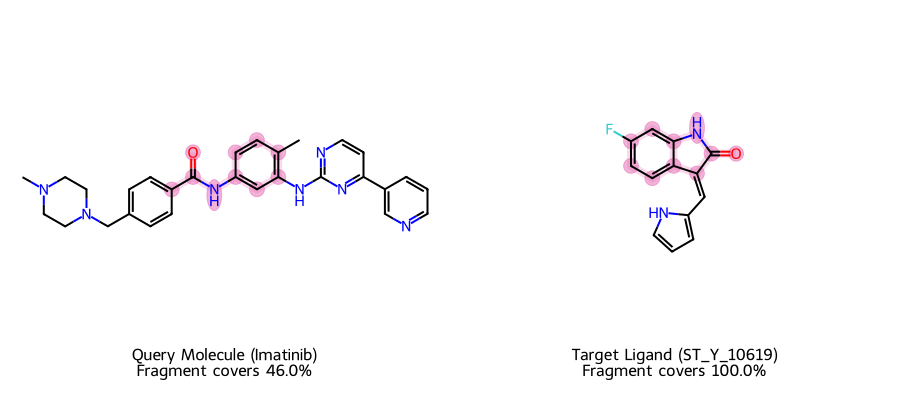

🎯 Target Protein:       Yeast_STITCH_T_11
🧬 Polypharmacy Class:   Type 2 (Monovalent Multitarget)
------------------------------------------------------------------------------------------
📊 METADATA PAYLOAD:
   • Database ID:        ST_Y_4967
   • Magnet ID:          MDB2095122
   • Query Coverage:     67.6%
   • Target Coverage:    96.2%
   • Query Atom Count:   37
------------------------------------------------------------------------------------------
🔗 Shared Fragment:      *c1cc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)ccc1C
⬅️ From Query Molecule:  CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C)NC4=NC=CC(=N4)C5=CN=CC=C5
➡️ Maps to Target Ligand: C1=CC=C2C(=C1)C=CC(=N2)NC(=O)C3=NSC=C3NCC4=CC=NC=C4
Query (Full) Functional Groups:  carbonyl compound (1), amide (1), secondary amine (2), tertiary amine (2), pyridine (1), pyrimidine (1)
Target (Full) Functional Groups: carbonyl compound (1), amide (1), secondary amine (2), pyridine (2)



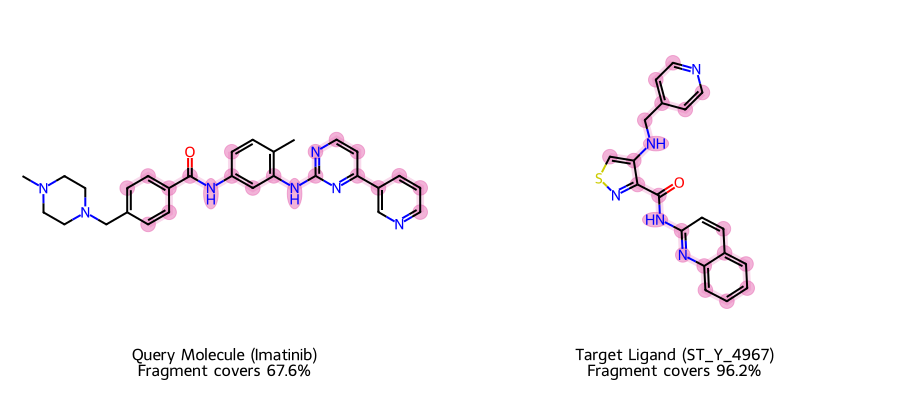

🎯 Target Protein:       SMS_T_208
🧬 Polypharmacy Class:   Type 2 (Monovalent Multitarget)
------------------------------------------------------------------------------------------
📊 METADATA PAYLOAD:
   • Database ID:        SMS_939791
   • Magnet ID:          MDB0731935
   • Query Coverage:     59.5%
   • Target Coverage:    91.7%
   • Query Atom Count:   37
------------------------------------------------------------------------------------------
🔗 Shared Fragment:      *Nc1ccc(C)c(Nc2nccc(-c3cccnc3)n2)c1
⬅️ From Query Molecule:  CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C)NC4=NC=CC(=N4)C5=CN=CC=C5
➡️ Maps to Target Ligand: CC(=O)Nc1ccc(C)c(Nc2nccc(-c3cccnc3)n2)c1
Query (Full) Functional Groups:  carbonyl compound (1), amide (1), secondary amine (2), tertiary amine (2), pyridine (1), pyrimidine (1)
Target (Full) Functional Groups: carbonyl compound (1), ketone (1), amide (1), secondary amine (2), pyridine (1), pyrimidine (1)



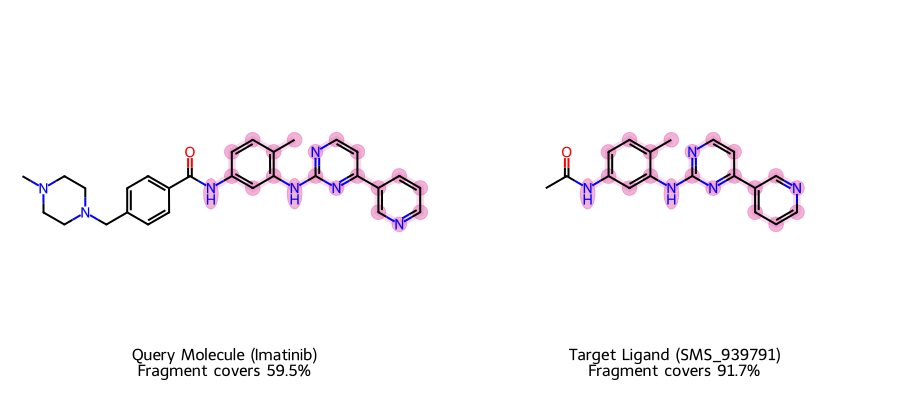

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Draw, Recap, rdFMCS
from rdkit.Chem.rdmolops import DeleteSubstructs
from rdkit.Chem.Draw import rdDepictor
from rdkit import RDLogger
from IPython.display import display

# =====================================================================
# 1. VISUALIZATION STYLING & CLEANUP
# =====================================================================
RDLogger.DisableLog('rdApp.*') # Mutes strict RDKit SMARTS warnings

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "axes.linewidth": 1.0,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out"
})

# =====================================================================
# 2. MASTER CHEMICAL GROUPS DICTIONARY
# =====================================================================
MASTER_CHEMICAL_GROUPS = {
    'cation': {'smarts': '[+]'},
    'anion': {'smarts': '[-]'},
    'carbonyl compound': {'smarts': 'C=O'},
    'ketone': {'smarts': 'C(=O)C'},
    'thiocarbonyl compound': {'smarts': 'C=S'},
    'imine': {'smarts': 'C=N'},
    'hydrazone': {'smarts': 'C=N-N'},
    'oxime': {'smarts': 'C=N-[OH]'},
    'ether': {'smarts': 'C-O-C'},
    'carboxylic acid': {'smarts': 'C(=O)[OH]'},
    'ester': {'smarts': 'C(=O)O-C'},
    'amide': {'smarts': 'C(=O)N'},
    'primary amine': {'smarts': '[NX3H2]'},
    'secondary amine': {'smarts': '[NX3H1]'},
    'tertiary amine': {'smarts': '[NX3H0]'},
    'alcohol': {'smarts': '[OX2H]'},
    'phenol': {'smarts': 'c1ccccc1[OH]'},
    'thiol': {'smarts': '[SX2H]'},
    'thioether': {'smarts': 'C-S-C'},
    'disulfide': {'smarts': 'S-S'},
    'sulfonamide': {'smarts': 'S(=O)(=O)N'},
    'sulfone': {'smarts': 'S(=O)(=O)C'},
    'sulfonic acid': {'smarts': 'S(=O)(=O)[OH]'},
    'phosphate': {'smarts': 'O=P(O)(O)O'},
    'halogen': {'smarts': '[F,Cl,Br,I]'},
    'trifluoromethyl': {'smarts': 'C(F)(F)F'},
    'cyanide / nitrile': {'smarts': 'C#N'},
    'nitro': {'smarts': 'N(=O)=O'},
    'azide': {'smarts': 'N=N=N'},
    'alkyne': {'smarts': 'C#C'},
    'alkene': {'smarts': 'C=C'},
    'furan': {'smarts': 'c1cocc1'},
    'thiophene': {'smarts': 'c1cscc1'},
    'pyrrole': {'smarts': 'c1cc[nH]c1'},
    'pyridine': {'smarts': 'c1ccncc1'},
    'pyrimidine': {'smarts': 'c1cncnc1'},
    'imidazole': {'smarts': 'c1c[nH]cn1'},
    'pyrazole': {'smarts': 'c1c[nH]nc1'},
}

def identify_functional_groups(mol):
    detected = []
    for name, properties in MASTER_CHEMICAL_GROUPS.items():
        pattern = Chem.MolFromSmarts(properties['smarts'])
        if pattern is None: continue 
        matches = mol.GetSubstructMatches(pattern)
        if matches: detected.append(f"{name} ({len(matches)})")
    return ", ".join(detected) if detected else "None"

# =====================================================================
# 3. POLYPHARMACOLOGY TYPE ANALYSIS & NOMENCLATURE
# =====================================================================
TYPE_NAMES = {
    "Type 1": "Type 1 (Monovalent Monotarget)",
    "Type 2": "Type 2 (Monovalent Multitarget)",
    "Type 3": "Type 3 (Multivalent Monotarget)",
    "Type 4": "Type 4 (Multivalent Multitarget)",
    "Type 5": "Type 5 (Unclassified)"
}

def get_mcs_smile(query_mol, target_mol):
    if query_mol is None or target_mol is None: return None
    mcs = rdFMCS.FindMCS([query_mol, target_mol], timeout=3)
    if mcs is None or not mcs.smartsString: return None
    return Chem.MolToSmiles(Chem.MolFromSmarts(mcs.smartsString), isomericSmiles=True)

def perform_type_analysis(df, parent_smiles):
    print("--- Running Type Analysis ---")
    unique_queries = set(df['query_frag_smile'].unique())
    unique_target_count = df['Target_ID'].nunique()
    
    molecule = Chem.MolFromSmiles(parent_smiles)
    hierarchy = Recap.RecapDecompose(molecule)
    first_level_keys = sorted(hierarchy.children.keys())

    if len(first_level_keys) < 2:
        df['Polypharmacology_Type'] = "Type 1" if unique_target_count == 1 else "Type 2"
        return df

    query_frag = Chem.MolToSmiles(hierarchy.children[first_level_keys[0]].mol, isomericSmiles=True)
    query_frag_mol = Chem.MolFromSmiles(query_frag)
    s1map_list = [query_frag]
    s2map_list = []

    for i in range(1, len(first_level_keys)):
        target_frag = Chem.MolToSmiles(hierarchy.children[first_level_keys[i]].mol, isomericSmiles=True)
        target_frag_mol = Chem.MolFromSmiles(target_frag)
        mcs_smile = get_mcs_smile(query_frag_mol, target_frag_mol)

        if mcs_smile == Chem.MolToSmiles(query_frag_mol, isomericSmiles=True):
            s1map_list.append(target_frag)
        else:
            s2map_list.append(target_frag)

    s1_match = s2_match = False
    for query in unique_queries:
        for s1_frag in s1map_list:
            if get_mcs_smile(Chem.MolFromSmiles(s1_frag), Chem.MolFromSmiles(query)) == query: s1_match = True
        for s2_frag in s2map_list:
            if get_mcs_smile(Chem.MolFromSmiles(s2_frag), Chem.MolFromSmiles(query)) == query: s2_match = True

    query_count = len(unique_queries)
    if query_count < 1: result = "Type 5"
    elif query_count == 1: result = "Type 1" if unique_target_count == 1 else "Type 2"
    else:
        if not s1_match and not s2_match: result = "Type 1" if unique_target_count == 1 else "Type 2"
        else: result = "Type 3" if unique_target_count == 1 else "Type 4"

    df['Polypharmacology_Type'] = result
    return df

# =====================================================================
# 4. MAIN PIPELINE (Filter -> Analyze -> Visualize)
# =====================================================================
def analyze_and_visualize(csv_path, parent_smiles):
    print(f"Loading data from {csv_path}...")
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: {csv_path} not found.")
        return

    # 1. APPLY FILTERS
    df = df[df['query_smile_atom_count'] >= 10]
    df = df[df["Query_Percentage"] >= 25]
    df = df[df["Target_Percentage"] >= 75]
    df = df[df["Target_Percentage"] <= 100.0]

    if len(df) == 0:
        print("⚠️ No matches survived the filtering thresholds.")
        return

    # 2. RUN TYPE ANALYSIS
    df = perform_type_analysis(df, parent_smiles)
    
    # 3. DENSITY PLOTS
    unique_queries = df['query_smile_atom_count'].nunique()
    if unique_queries > 1 and len(df) > 1:
        print("Drawing 1x3 Density Grid...")
        fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
        sns.kdeplot(data=df, x='query_smile_atom_count', fill=True, ax=axes[0], color='blue', warn_singular=False)
        axes[0].set_title('Query Atom Count Density')
        sns.kdeplot(data=df, x='Query_Percentage', fill=True, ax=axes[1], color='green', warn_singular=False)
        axes[1].set_title('Query Coverage Density (%)')
        sns.kdeplot(data=df, x='Target_Percentage', fill=True, ax=axes[2], color='red', warn_singular=False)
        axes[2].set_title('Target Coverage Density (%)')
        plt.tight_layout()
        plt.show()

    # 4. HIGHLIGHT MAPPED FRAGMENTS IN FULL MOLECULES
    print("\nHighlighting shared fragments within the FULL Parent Molecules...")
    rdDepictor.SetPreferCoordGen(True)
    
    # Custom aesthetic settings 
    dopts = Draw.rdMolDraw2D.MolDrawOptions()
    dopts.continuousHighlight = True               
    dopts.setHighlightColour((0.9, 0.4, 0.7, 0.5)) 
    
    # Get Top 3 unique targets for display
    vis_df = df.drop_duplicates(subset=['Target_ID', 'query_frag_smile']).head(3)
    parent_mol = Chem.MolFromSmiles(parent_smiles)
    
    for i, row in vis_df.iterrows():
        raw_type = row['Polypharmacology_Type']
        descriptive_type = TYPE_NAMES.get(raw_type, raw_type)
        
        # ---------------------------------------------------------
        # NEW: EXPLICIT METADATA PRINTOUT
        # ---------------------------------------------------------
        print("=" * 90)
        print(f"🎯 Target Protein:       {row.get('Target_ID', 'Unknown')}")
        print(f"🧬 Polypharmacy Class:   {descriptive_type}")
        print("-" * 90)
        print("📊 METADATA PAYLOAD:")
        print(f"   • Database ID:        {row.get('Database_ID', 'N/A')}")
        print(f"   • Magnet ID:          {row.get('Magnet_ID', 'N/A')}")
        print(f"   • Query Coverage:     {row['Query_Percentage']:.1f}%")
        print(f"   • Target Coverage:    {row['Target_Percentage']:.1f}%")
        print(f"   • Query Atom Count:   {row['query_smile_atom_count']}")
        print("-" * 90)
        print(f"🔗 Shared Fragment:      {row['query_frag_smile']}")
        print(f"⬅️ From Query Molecule:  {parent_smiles}")
        print(f"➡️ Maps to Target Ligand: {row['original_target_smile']}")
        print("=" * 90)
        
        t_mol = Chem.MolFromSmiles(row['original_target_smile'])

        if not parent_mol or not t_mol:
            continue

        # ---------------------------------------------------------
        # THE FIX: Highlight the EXACT fragment instead of guessing
        # ---------------------------------------------------------
        frag_mol = Chem.MolFromSmiles(row['query_frag_smile'])
        dummy_atom = Chem.MolFromSmarts('[#0]') 
        clean_frag = DeleteSubstructs(frag_mol, dummy_atom)
        
        match_parent = parent_mol.GetSubstructMatch(clean_frag)
        match_target = t_mol.GetSubstructMatch(clean_frag)

        if not match_parent or not match_target:
            mcs = rdFMCS.FindMCS([parent_mol, t_mol], timeout=5)
            if mcs and mcs.smartsString:
                mcs_mol = Chem.MolFromSmarts(mcs.smartsString)
                match_parent = parent_mol.GetSubstructMatch(mcs_mol)
                match_target = t_mol.GetSubstructMatch(mcs_mol)
        
        print(f"Query (Full) Functional Groups:  {identify_functional_groups(parent_mol)}")
        print(f"Target (Full) Functional Groups: {identify_functional_groups(t_mol)}\n")

        img = Draw.MolsToGridImage(
            [parent_mol, t_mol],
            highlightAtomLists=[list(match_parent), list(match_target)],
            legends=[f"Query Molecule (Imatinib)\nFragment covers {row['Query_Percentage']:.1f}%", 
                     f"Target Ligand ({row['Database_ID']})\nFragment covers {row['Target_Percentage']:.1f}%"],
            molsPerRow=2,
            subImgSize=(450, 400),
            useSVG=True,
            drawOptions=dopts
        )
        display(img)

if __name__ == "__main__":
    IMATINIB_SMILES = "CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C)NC4=NC=CC(=N4)C5=CN=CC=C5"
    analyze_and_visualize("Imatinib_Mapped_Targets.csv", IMATINIB_SMILES)
    

# improved version 

# build_enriched_trie

In [23]:
import os
import sys
import time
import pickle
import pandas as pd
from tqdm import tqdm

sys.setrecursionlimit(50000)

FINAL_MAGNET_CSV = "/storage/savi/saveenas/Projects/Magnet/Dataset/FINAL_MAGNET_DATABASE/Final_MagnetDB.csv"
DIRECT_BINDERS_PKL = "/storage/savi/saveenas/Projects/Magnet/Magnet_Package/Direct_Binders_Dictionary.pkl"
OUTPUT_TRIE_PKL = "Enriched_MagnetDB_Trie.pkl"

class TrieNode:
    def __init__(self):
        self.children = {}
        self.is_end_of_word = False
        self.metadata = [] 

class EnrichedTrie:
    def __init__(self):
        self.root = TrieNode()

    def insert(self, word, metadata_payload):
        node = self.root
        for char in word:
            if char not in node.children:
                node.children[char] = TrieNode()
            node = node.children[char]
        node.is_end_of_word = True
        node.metadata.extend(metadata_payload)

    def __getstate__(self):
        return self.root

    def __setstate__(self, state):
        self.root = state

if __name__ == "__main__":
    start = time.time()
    print("Loading Databases...")
    
    magnet_df = pd.read_csv(FINAL_MAGNET_CSV)
    with open(DIRECT_BINDERS_PKL, 'rb') as f:
        direct_binders_dict = pickle.load(f)

    trie = EnrichedTrie()
    
    fragments = magnet_df['Fragment'].astype(str).tolist()
    magnet_ids = magnet_df['Magnet Id'].astype(str).tolist()
    sources = magnet_df['Source'].astype(str).tolist()

    print("Building Enriched Trie with Extended Metadata...")
    for frag, magnet_id, source_str in tqdm(zip(fragments, magnet_ids, sources), total=len(fragments)):
        if frag == 'nan' or not frag: continue
            
        source_ids = source_str.split(', ') if source_str != 'nan' else []
        
        payload = []
        for source_id in source_ids:
            if source_id in direct_binders_dict:
                target_info = direct_binders_dict[source_id]
                
                # ---> EXTRACTING YOUR NEW METADATA HERE <---
                payload.append({
                    "Database_ID": source_id,
                    "Target_ID": target_info.get('Target ID', ''),
                    "Target_Name": target_info.get('Target', 'Unknown Protein'),
                    "Ligand_Name": target_info.get('Ligand Name', 'Unknown Ligand'),
                    "Organism": target_info.get('Organism', 'Unknown Organism'),
                    "Assay": target_info.get('Assay', 'No Assay Data'),
                    "Original_SMILES": target_info.get('SMILE', ''),
                    "Magnet_ID": magnet_id
                })
        
        if payload:
            trie.insert((frag + "$")[::-1], payload)
            
    print("Serializing Trie to disk...")
    with open(OUTPUT_TRIE_PKL, 'wb') as f:
        pickle.dump(trie, f, protocol=pickle.HIGHEST_PROTOCOL)
        
    print(f"✅ Trie built & saved successfully in {time.time() - start:.2f} seconds!")

Loading Databases...
Building Enriched Trie with Extended Metadata...


100%|██████████| 2471351/2471351 [04:08<00:00, 9933.39it/s] 


Serializing Trie to disk...
✅ Trie built & saved successfully in 484.56 seconds!


# inference.py 

In [25]:
import csv
import time
import pickle
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Recap
from rdkit.Chem.rdmolops import DeleteSubstructs

# =================================================================
# 1. DEFINE CLASSES LOCALLY (The Jupyter Fix!)
# =================================================================
class TrieNode:
    def __init__(self):
        self.children = {}
        self.is_end_of_word = False
        self.metadata = [] 

class EnrichedTrie:
    def __init__(self):
        self.root = TrieNode()

    def __getstate__(self):
        return self.root

    def __setstate__(self, state):
        self.root = state

# =================================================================
# 2. INFERENCE LOGIC (With Heavy Atom Math & Extended Metadata)
# =================================================================
def get_heavy_atom_count(smile):
    """Accurately counts heavy atoms by ignoring RECAP dummy atoms (*)"""
    try:
        mol = Chem.MolFromSmiles(smile)
        if not mol: return 0
        dummy = Chem.MolFromSmarts('[#0]') # Matches the '*' atom
        clean_mol = DeleteSubstructs(mol, dummy)
        return clean_mol.GetNumHeavyAtoms()
    except:
        return 0

def predict_targets(user_smiles, query_name="User_Molecule", min_query_cov=25.0, min_target_cov=75.0):
    print(f"\n{'='*50}\n🔍 SYNGLUE INFERENCE: {query_name}\n{'='*50}")
    
    t0_load = time.time()
    
    # Python uses the EnrichedTrie class defined right above to unpack this!
    with open("Enriched_MagnetDB_Trie.pkl", "rb") as f:
        trie = pickle.load(f)
    print(f"✅ Trie loaded in: {time.time() - t0_load:.4f} seconds.")
    
    t0_inference = time.time()
    mol = Chem.MolFromSmiles(user_smiles)
    hierarchy = Recap.RecapDecompose(mol)
    terminal_fragments = [smi for smi, node in hierarchy.children.items() if smi.count('*') == 1]
    
    q_smile_atoms = get_heavy_atom_count(user_smiles)
    results = []

    for frag in terminal_fragments:
        node = trie.root
        match_found = True
        for char in (frag + "$")[::-1]:
            if char not in node.children:
                match_found = False
                break
            node = node.children[char]
            
        if match_found and node.is_end_of_word:
            q_frag_atoms = get_heavy_atom_count(frag) # Clean fragment atom count
            
            for meta in node.metadata:
                t_smile_atoms = get_heavy_atom_count(meta["Original_SMILES"])
                
                # Math is now 100% accurate!
                q_cov = (q_frag_atoms / q_smile_atoms) * 100 if q_smile_atoms else 0
                t_cov = (q_frag_atoms / t_smile_atoms) * 100 if t_smile_atoms else 0
                
                if q_cov >= min_query_cov and t_cov >= min_target_cov:
                    results.append({
                        "Database_ID": meta["Database_ID"],
                        "Target_ID": meta["Target_ID"],
                        "Target_Name": meta["Target_Name"],
                        "Ligand_Name": meta["Ligand_Name"],
                        "Organism": meta["Organism"],
                        "Assay": meta["Assay"],
                        "Magnet_ID": meta["Magnet_ID"],
                        "query_frag_smile": frag,
                        "original_target_smile": meta["Original_SMILES"],
                        "query_smile_atom_count": q_smile_atoms,
                        "Query_Percentage": round(q_cov, 2),
                        "Target_Percentage": round(t_cov, 2)
                    })

    df_results = pd.DataFrame(results)
    if not df_results.empty:
        df_results = df_results.sort_values(by="Target_Percentage", ascending=False).reset_index(drop=True)
        out_csv = f"{query_name}_Mapped_Targets.csv"
        df_results.to_csv(out_csv, index=False)
        print(f"⚡ Inference completed in: {time.time() - t0_inference:.5f} seconds!")
        print(f"💾 Full results saved to {out_csv} ({len(df_results)} hits)")
    else:
        print("⚠️ No valid targets found passing the thresholds.")
        
    return df_results

if __name__ == "__main__":
    IMATINIB_SMILES = "CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C)NC4=NC=CC(=N4)C5=CN=CC=C5"
    predict_targets(user_smiles=IMATINIB_SMILES, query_name="Imatinib", min_query_cov=25.0, min_target_cov=75.0)


🔍 SYNGLUE INFERENCE: Imatinib
✅ Trie loaded in: 240.7526 seconds.
⚡ Inference completed in: 65.99754 seconds!
💾 Full results saved to Imatinib_Mapped_Targets.csv (9457 hits)


In [27]:
NN = pd.read_csv("Imatinib_Mapped_Targets.csv")
NN

,Database_ID,Target_ID,Target_Name,Ligand_Name,Organism,Assay,Magnet_ID,query_frag_smile,original_target_smile,query_smile_atom_count,Query_Percentage,Target_Percentage
0,ST_Y_10619,Yeast_STITCH_T_11,4932.YAL017W : PSK1,CIDm10074640 : masitinib,saccharomyces cerevisiae,Serine/threonine-protein kinase PSK1; PAS doma...,MDB2095122,*c1cc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)ccc1C,C1=CNC(=C1)C=C2C3=C(C=C(C=C3)F)NC2=O,37,64.86,141.18
1,ST_Y_12323,Yeast_STITCH_T_11,4932.YAL017W : PSK1,CIDm00005291 : imatinib,saccharomyces cerevisiae,Serine/threonine-protein kinase PSK1; PAS doma...,MDB1785496,*c1ccnc(Nc2cc(NC(=O)c3ccc(CN4CCN(C)CC4)cc3)ccc...,COC1=C(C=C2C(=C1)C(=C(C=N2)C#N)NC3=CC=C(C=C3)C...,37,83.78,129.17
2,ST_Y_12323,Yeast_STITCH_T_11,4932.YAL017W : PSK1,CIDm00005291 : imatinib,saccharomyces cerevisiae,Serine/threonine-protein kinase PSK1; PAS doma...,MDB1152765,*Cc1ccc(C(=O)Nc2ccc(C)c(Nc3nccc(-c4cccnc4)n3)c...,COC1=C(C=C2C(=C1)C(=C(C=N2)C#N)NC3=CC=C(C=C3)C...,37,81.08,125.00
3,ST_Y_7653,Yeast_STITCH_T_11,4932.YAL017W : PSK1,CIDm24897305 : KB-74970,saccharomyces cerevisiae,Serine/threonine-protein kinase PSK1; PAS doma...,MDB1785496,*c1ccnc(Nc2cc(NC(=O)c3ccc(CN4CCN(C)CC4)cc3)ccc...,C1OC2=C(O1)C(=C(C=C2)Cl)NC3=NC(=NC=C3)NC4=CC=C...,37,83.78,110.71
4,ST_Y_81334,Yeast_STITCH_T_705,4932.YPL204W : HRR25,CIDm71655784 : AGN-PC-0JICLZ,saccharomyces cerevisiae,Conserved casein kinase; regulates diverse eve...,MDB2136675,*c1nccc(-c2cccnc2)n1,C1=CC=C2C(=C1)N=C(S2)CN,37,32.43,109.09
...,...,...,...,...,...,...,...,...,...,...,...,...
9452,SMS_2870909,SMS_T_1098,"441: , 613.0, Breakpoint cluster region protei...",CHEMBL3098615: nan,Homo sapiens,Binding constant for FGFR1 kinase domain,MDB1152765,*Cc1ccc(C(=O)Nc2ccc(C)c(Nc3nccc(-c4cccnc4)n3)c...,Cc1ccc(NC(=O)c2ccc(CN3CCN(CCO)CC3)cc2)cc1Nc1nc...,37,81.08,76.92
9453,SMS_2861824,SMS_T_1097,"36: , 25.0, Tyrosine-protein kinase ABL Inhibi...",CHEMBL3098616: nan,Homo sapiens,PUBCHEM_BIOASSAY: Navigating the Kinome. (Clas...,MDB1152765,*Cc1ccc(C(=O)Nc2ccc(C)c(Nc3nccc(-c4cccnc4)n3)c...,Cc1ccc(NC(=O)c2ccc(CN3CCN(CCF)CC3)cc2)cc1Nc1nc...,37,81.08,76.92
9454,BD1146495,BD_T_611,Bcr-Abl,CHEMBL3098616 : :,Homo sapiens,NaN,MDB1152765,*Cc1ccc(C(=O)Nc2ccc(C)c(Nc3nccc(-c4cccnc4)n3)c...,Cc1ccc(NC(=O)c2ccc(CN3CCN(CCF)CC3)cc2)cc1Nc1nc...,37,81.08,76.92
9455,SMS_2861825,SMS_T_1096,"36: , 25.0, Tyrosine-protein kinase ABL Inhibi...",CHEMBL3098616: nan,Homo sapiens,PUBCHEM_BIOASSAY: Navigating the Kinome. (Clas...,MDB1152765,*Cc1ccc(C(=O)Nc2ccc(C)c(Nc3nccc(-c4cccnc4)n3)c...,Cc1ccc(NC(=O)c2ccc(CN3CCN(CCF)CC3)cc2)cc1Nc1nc...,37,81.08,76.92


# analyse and visualise 

Loading data from Imatinib_Mapped_Targets.csv...

Highlighting shared fragments within the FULL Parent Molecules...

🎯 Target Protein:      Yeast_STITCH_T_11
📝 Full Protein Name:   4932.YAL017W : PSK1
🦠 Organism:            saccharomyces cerevisiae
------------------------------------------------------------------------------------------
📊 METADATA PAYLOAD:
   • Database ID:       ST_Y_4964
   • Ligand Name:       CIDm44580689 : AGN-PC-077MJ7
   • Assay Info:        Serine/threonine-protein kinase PSK1; PAS domain-containing serine/threonine protein kinase; coordin...
   • Magnet ID:         MDB2095122
   • Query Coverage:    64.9%
   • Target Coverage:   100.0%
------------------------------------------------------------------------------------------
🔗 Shared Fragment:     *c1cc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)ccc1C


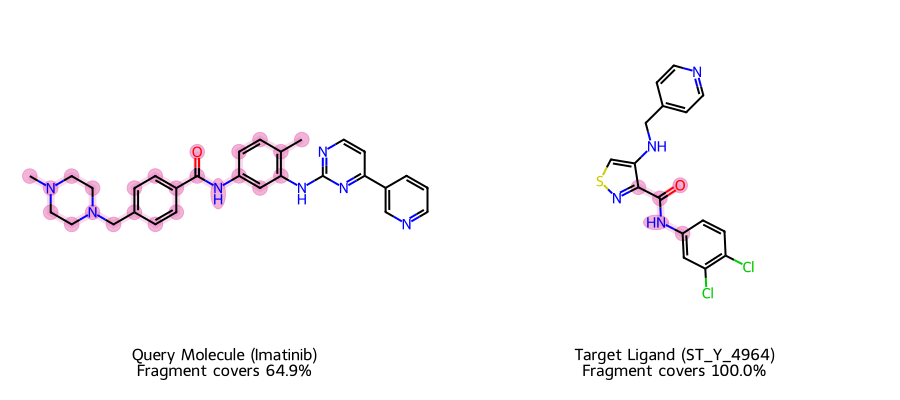


🎯 Target Protein:      Yeast_STITCH_T_11
📝 Full Protein Name:   4932.YAL017W : PSK1
🦠 Organism:            saccharomyces cerevisiae
------------------------------------------------------------------------------------------
📊 METADATA PAYLOAD:
   • Database ID:       ST_Y_10619
   • Ligand Name:       CIDm10074640 : masitinib
   • Assay Info:        Serine/threonine-protein kinase PSK1; PAS domain-containing serine/threonine protein kinase; coordin...
   • Magnet ID:         MDB0620252
   • Query Coverage:    43.2%
   • Target Coverage:   94.1%
------------------------------------------------------------------------------------------
🔗 Shared Fragment:     *C(=O)c1ccc(CN2CCN(C)CC2)cc1


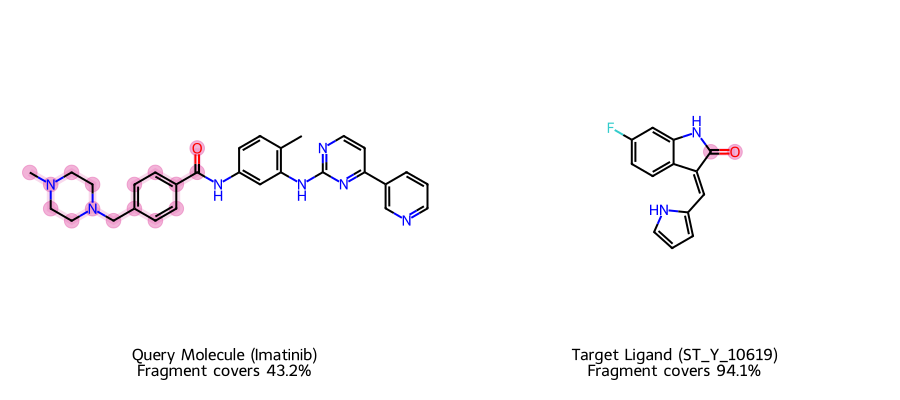


🎯 Target Protein:      SMS_T_208
📝 Full Protein Name:   3466: , 5156.0, Platelet-derived growth factor receptor alpha Inhibition of the platelet-derived growth factor receptor.: PDGFRA: , P16234, PROTEIN-PROTEIN INTERACTION, CHEMBL4630733
🦠 Organism:            Homo sapiens
------------------------------------------------------------------------------------------
📊 METADATA PAYLOAD:
   • Database ID:       SMS_939796
   • Ligand Name:       CHEMBL423288: nan
   • Assay Info:        PubChem BioAssay. qHTS Assay for Inhibitors of MBNL1-poly(CUG) RNA binding.   (Class of assay: confi...
   • Magnet ID:         MDB0731935
   • Query Coverage:    56.8%
   • Target Coverage:   87.5%
------------------------------------------------------------------------------------------
🔗 Shared Fragment:     *Nc1ccc(C)c(Nc2nccc(-c3cccnc3)n2)c1


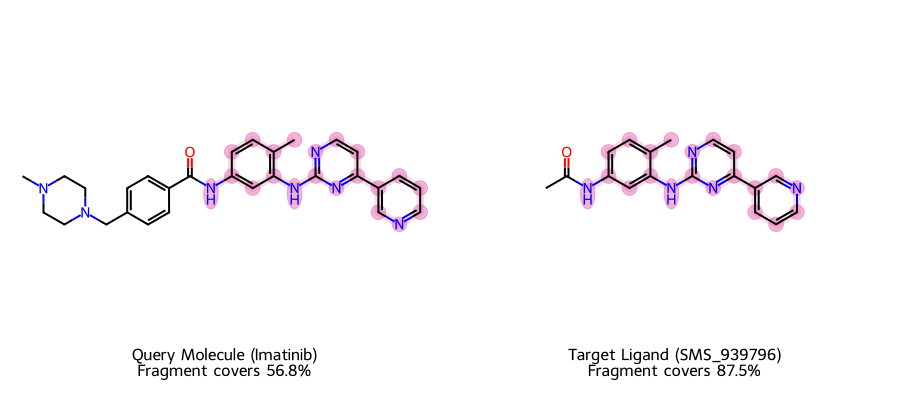

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Draw, Recap, rdFMCS
from rdkit.Chem.rdmolops import DeleteSubstructs
from rdkit.Chem.Draw import rdDepictor
from rdkit import RDLogger
from IPython.display import display

RDLogger.DisableLog('rdApp.*')

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)

# Function to safely find and highlight a fragment inside a larger molecule
def get_robust_highlight(full_mol, frag_smile):
    frag_mol = Chem.MolFromSmiles(frag_smile)
    dummy_atom = Chem.MolFromSmarts('[#0]') 
    clean_frag = DeleteSubstructs(frag_mol, dummy_atom)
    
    # Try exact substructure match first
    match = full_mol.GetSubstructMatch(clean_frag)
    if match: return list(match)
    
    # Fallback: RDKit MCS if aromaticity is drawn differently
    mcs = rdFMCS.FindMCS([full_mol, clean_frag], timeout=3, completeRingsOnly=True)
    if mcs and mcs.smartsString:
        mcs_mol = Chem.MolFromSmarts(mcs.smartsString)
        return list(full_mol.GetSubstructMatch(mcs_mol))
    return []

def analyze_and_visualize(csv_path, parent_smiles):
    print(f"Loading data from {csv_path}...")
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        return

    # Filter invalid physical percentages 
    df = df[df["Target_Percentage"] <= 100.0]

    # ... [Keep the 1x3 Density Plot code here from the previous script] ...

    print("\nHighlighting shared fragments within the FULL Parent Molecules...")
    rdDepictor.SetPreferCoordGen(True)
    dopts = Draw.rdMolDraw2D.MolDrawOptions()
    dopts.continuousHighlight = True               
    dopts.setHighlightColour((0.9, 0.4, 0.7, 0.5)) 
    
    vis_df = df.drop_duplicates(subset=['Target_ID', 'query_frag_smile']).head(3)
    parent_mol = Chem.MolFromSmiles(parent_smiles)
    
    for i, row in vis_df.iterrows():
        print("\n" + "=" * 90)
        print(f"🎯 Target Protein:      {row.get('Target_ID', 'Unknown')}")
        print(f"📝 Full Protein Name:   {row.get('Target_Name', 'Unknown')}")
        print(f"🦠 Organism:            {row.get('Organism', 'Unknown')}")
        print("-" * 90)
        print("📊 METADATA PAYLOAD:")
        print(f"   • Database ID:       {row.get('Database_ID', 'N/A')}")
        print(f"   • Ligand Name:       {row.get('Ligand_Name', 'N/A')}")
        print(f"   • Assay Info:        {row.get('Assay', 'N/A')[:100]}...") # Truncated so it doesn't flood screen
        print(f"   • Magnet ID:         {row.get('Magnet_ID', 'N/A')}")
        print(f"   • Query Coverage:    {row['Query_Percentage']:.1f}%")
        print(f"   • Target Coverage:   {row['Target_Percentage']:.1f}%")
        print("-" * 90)
        print(f"🔗 Shared Fragment:     {row['query_frag_smile']}")
        print("=" * 90)
        
        t_mol = Chem.MolFromSmiles(row['original_target_smile'])
        if not parent_mol or not t_mol: continue

        # The new robust highlighting mechanism
        match_parent = get_robust_highlight(parent_mol, row['query_frag_smile'])
        match_target = get_robust_highlight(t_mol, row['query_frag_smile'])

        img = Draw.MolsToGridImage(
            [parent_mol, t_mol],
            highlightAtomLists=[match_parent, match_target],
            legends=[f"Query Molecule (Imatinib)\nFragment covers {row['Query_Percentage']:.1f}%", 
                     f"Target Ligand ({row['Database_ID']})\nFragment covers {row['Target_Percentage']:.1f}%"],
            molsPerRow=2,
            subImgSize=(450, 400),
            useSVG=True,
            drawOptions=dopts
        )
        display(img)

if __name__ == "__main__":
    IMATINIB_SMILES = "CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C)NC4=NC=CC(=N4)C5=CN=CC=C5"
    analyze_and_visualize("Imatinib_Mapped_Targets.csv", IMATINIB_SMILES)

In [28]:
import pickle
from rdkit import Chem
from rdkit import RDLogger

# Suppress RDKit warnings for a clean output
RDLogger.DisableLog('rdApp.*')

# 1. Load the Raw Database
binders_path = "/storage/savi/saveenas/Projects/Magnet/Magnet_Package/Direct_Binders_Dictionary.pkl"
print("Loading Direct Binders Dictionary...")
with open(binders_path, 'rb') as f:
    binders_dict = pickle.load(f)

print(f"✅ Loaded {len(binders_dict)} total entries.\n")

# =========================================================
# TOOL A: The "Tiny Molecule" Hunter
# =========================================================
print("🔍 Hunting for corrupted/tiny SMILES (Under 6 heavy atoms)...")
anomaly_count = 0

# We will scan the dictionary to find physically impossible "drugs"
for db_id, data in binders_dict.items():
    smiles = str(data.get('SMILE', ''))
    
    # Skip empty SMILES
    if not smiles or smiles == 'nan':
        continue
        
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        atom_count = mol.GetNumHeavyAtoms()
        
        # If the entire "target drug" is less than 6 atoms, it's an anomaly!
        if 0 < atom_count < 6:
            print("-" * 60)
            print(f"🚨 Anomaly Found: {db_id}")
            print(f"   Ligand Name:   {data.get('Ligand Name', 'Unknown')}")
            print(f"   Target:        {data.get('Target ID', 'Unknown')}")
            print(f"   Raw SMILES:    {smiles} (Only {atom_count} atoms!)")
            
            anomaly_count += 1
            if anomaly_count >= 10: # Stop after finding the first 10
                print("-" * 60)
                print("... stopping scan after 10 examples.")
                break

# =========================================================
# TOOL B: Specific ID Lookup
# =========================================================
# If you found the specific Database_ID for the 141% hit in your CSV, 
# you can type it here to see exactly what its raw data looks like!
suspicious_id = "ENTER_ID_HERE" 

if suspicious_id in binders_dict:
    print(f"\n🔬 Deep Dive into {suspicious_id}:")
    for key, value in binders_dict[suspicious_id].items():
        print(f"   {key}: {value}")

Loading Direct Binders Dictionary...
✅ Loaded 5633814 total entries.

🔍 Hunting for corrupted/tiny SMILES (Under 6 heavy atoms)...
------------------------------------------------------------
🚨 Anomaly Found: CHEMBL1385560
   Ligand Name:   CHEMBL1385560 : 
   Target:        ChEMBL_T_1921
   Raw SMILES:    ClC=CCl (Only 4 atoms!)
------------------------------------------------------------
🚨 Anomaly Found: CHEMBL1353
   Ligand Name:   CHEMBL1353 : SODIUM BICARBONATE
   Target:        ChEMBL_T_2488
   Raw SMILES:    O=C([O-])O.[Na+] (Only 5 atoms!)
------------------------------------------------------------
🚨 Anomaly Found: CHEMBL376280
   Ligand Name:   CHEMBL376280 : IODOACETIC ACID
   Target:        ChEMBL_T_2616
   Raw SMILES:    O=C(O)CI (Only 5 atoms!)
------------------------------------------------------------
🚨 Anomaly Found: BD35741
   Ligand Name:   CHEMBL363707::HCO3-::SODIUM BICARBONATE::bicarbonate ion::hydrogen carbonate : ZINC06827693 : DB01390
   Target:        BD_T_22

KeyboardInterrupt: 

# final Test 

In [29]:
import os
import sys
import time
import pickle
import pandas as pd
from tqdm import tqdm
from rdkit import Chem
from rdkit.Chem.rdmolops import DeleteSubstructs
from rdkit import RDLogger

# Mute RDKit warnings for a clean console
RDLogger.DisableLog('rdApp.*')
sys.setrecursionlimit(50000)

FINAL_MAGNET_CSV = "/storage/savi/saveenas/Projects/Magnet/Dataset/FINAL_MAGNET_DATABASE/Final_MagnetDB.csv"
DIRECT_BINDERS_PKL = "/storage/savi/saveenas/Projects/Magnet/Magnet_Package/Direct_Binders_Dictionary.pkl"
OUTPUT_TRIE_PKL = "Enriched_MagnetDB_Trie.pkl"

# =================================================================
# 1. TRIE CLASSES
# =================================================================
class TrieNode:
    def __init__(self):
        self.children = {}
        self.is_end_of_word = False
        self.metadata = [] 

class EnrichedTrie:
    def __init__(self):
        self.root = TrieNode()

    def insert(self, word, metadata_payload):
        node = self.root
        for char in word:
            if char not in node.children:
                node.children[char] = TrieNode()
            node = node.children[char]
        node.is_end_of_word = True
        node.metadata.extend(metadata_payload)

    def __getstate__(self):
        return self.root

    def __setstate__(self, state):
        self.root = state

# =================================================================
# 2. SANITY FILTER HELPER
# =================================================================
def get_heavy_atom_count(smile):
    """Accurately counts heavy atoms by ignoring RECAP dummy atoms (*)"""
    try:
        mol = Chem.MolFromSmiles(smile)
        if not mol: return 0
        dummy = Chem.MolFromSmarts('[#0]') 
        clean_mol = DeleteSubstructs(mol, dummy)
        return clean_mol.GetNumHeavyAtoms()
    except:
        return 0

# =================================================================
# 3. BUILD ROUTINE
# =================================================================
if __name__ == "__main__":
    start = time.time()
    print("Loading Databases...")
    
    magnet_df = pd.read_csv(FINAL_MAGNET_CSV)
    with open(DIRECT_BINDERS_PKL, 'rb') as f:
        direct_binders_dict = pickle.load(f)

    trie = EnrichedTrie()
    
    fragments = magnet_df['Fragment'].astype(str).tolist()
    magnet_ids = magnet_df['Magnet Id'].astype(str).tolist()
    sources = magnet_df['Source'].astype(str).tolist()

    print("Building Enriched Trie with Extended Metadata & Size Filters...")
    
    dropped_count = 0 # Let's track how much junk we filter out!
    
    for frag, magnet_id, source_str in tqdm(zip(fragments, magnet_ids, sources), total=len(fragments)):
        if frag == 'nan' or not frag: continue
            
        source_ids = source_str.split(', ') if source_str != 'nan' else []
        
        payload = []
        for source_id in source_ids:
            if source_id in direct_binders_dict:
                target_info = direct_binders_dict[source_id]
                raw_smiles = str(target_info.get('SMILE', ''))
                
                # ---> THE ROOT FIX: DROP TINY JUNK MOLECULES <---
                if get_heavy_atom_count(raw_smiles) < 8:
                    dropped_count += 1
                    continue 
                
                payload.append({
                    "Database_ID": source_id,
                    "Target_ID": target_info.get('Target ID', ''),
                    "Target_Name": target_info.get('Target', 'Unknown Protein'),
                    "Ligand_Name": target_info.get('Ligand Name', 'Unknown Ligand'),
                    "Organism": target_info.get('Organism', 'Unknown Organism'),
                    "Assay": target_info.get('Assay', 'No Assay Data'),
                    "Original_SMILES": raw_smiles,
                    "Magnet_ID": magnet_id
                })
        
        if payload:
            trie.insert((frag + "$")[::-1], payload)
            
    print(f"\n🗑️ Successfully dropped {dropped_count} corrupted/tiny targets!")
    print("Serializing cleaned Trie to disk...")
    with open(OUTPUT_TRIE_PKL, 'wb') as f:
        pickle.dump(trie, f, protocol=pickle.HIGHEST_PROTOCOL)
        4
    print(f"✅ Clean Trie built & saved successfully in {time.time() - start:.2f} seconds!")

Loading Databases...
Building Enriched Trie with Extended Metadata & Size Filters...


100%|██████████| 2471351/2471351 [2:40:31<00:00, 256.59it/s]   



🗑️ Successfully dropped 5527 corrupted/tiny targets!
Serializing cleaned Trie to disk...
✅ Clean Trie built & saved successfully in 9887.02 seconds!


In [2]:
import pandas as pd

csv_path = "/storage/savi/saveenas/Projects/Magnet/Dataset/FINAL_MAGNET_DATABASE/Final_MagnetDB.csv"

print("--- First 5 rows of Final_MagnetDB.csv ---")
df_sample = pd.read_csv(csv_path, nrows=5)
print(df_sample.to_string())
print("\nColumns available:", df_sample.columns.tolist())

--- First 5 rows of Final_MagnetDB.csv ---
                                                   Fragment   Magnet Id                                                                                                                                                                                                                   SMILES                                                                                             Source
0                          *c1ccc(N2CCC3(CC2)C[C@@H]3CO)cc1  MDB2471351                                                                                      "=Cc1nc(N2CCCCCC2)nc(Nc2ccc(N3CCC4(CC3)C[C@@H]4CO)cc2)c1C(N)=, #CCC1CCN(c2nc(C=N)c(C(N)=O)c(Nc3ccc(N4CCC5(CC4)C[C@@H]5CO)cc3)n2)CC"                                         BD470079, BD338771, BD470077, BD338770, BD338772, BD470078
1             *n1c(SC(C)C#N)nnc1-c1cccc(S(=O)(=O)N(CC)CC)c1  MDB2471350                                                                                                              

In [3]:
df_sample

,Fragment,Magnet Id,SMILES,Source
0,*c1ccc(N2CCC3(CC2)C[C@@H]3CO)cc1,MDB2471351,"""=Cc1nc(N2CCCCCC2)nc(Nc2ccc(N3CCC4(CC3)C[C@@H]...","BD470079, BD338771, BD470077, BD338770, BD3387..."
1,*n1c(SC(C)C#N)nnc1-c1cccc(S(=O)(=O)N(CC)CC)c1,MDB2471350,"""CN(CC)S(=O)(=O)c1cccc(-c2nnc(SC(C)C#N)n2Cc2cc...",CHEMBL1549053
2,*c1cc(NC(=O)CSCC(=O)Nc2cc(OC)c(OC)c(OC)c2)n(-c...,MDB2471349,"""Oc1cc(NC(=O)CSCC(=O)Nc2cc(-c3cc(C)c(C)cc3C)nn...","SMS_3717711, SMS_3717710"
3,*C(=O)CSc1nc(CCC)cc(=O)[nH]1,MDB2471348,"""CCc1cc(=O)[nH]c(SCC(=O)N(CCC#N)c2ccc3c(c2)OCC...","SMS_517131, SMS_517130, BD112077, BD1285560, B..."
4,*c1ccc(Nc2ccc([C@@H]3CCCO3)c(CN(C)C)n2)c2c1CNC2=O,MDB2471347,"""N(C)Cc1nc(Nc2ccc(-c3cnc4cc(F)ccn34)c3c2C(=O)N...","BD537447, BD533590, BD531609, BD547644"


In [4]:
import pickle

dict_path = "/storage/savi/saveenas/Projects/Magnet/Magnet_Package/Working_Module_2/Workflow/data/Final_MagnetDB_Dictionary.pkl"

with open(dict_path, 'rb') as f:
    magnet_dict = pickle.load(f)

print(f"--- MagnetDB Dictionary Loaded (Total Keys: {len(magnet_dict)}) ---")

# Get the first key in the dictionary
first_key = list(magnet_dict.keys())[0]

print(f"\nSample Key: {first_key}")
print(f"Sample Value:\n{magnet_dict[first_key]}")

--- MagnetDB Dictionary Loaded (Total Keys: 2471351) ---

Sample Key: MDB2471351
Sample Value:
{'Fragment': '*c1ccc(N2CCC3(CC2)C[C@@H]3CO)cc1', 'Source SMILES': '"=Cc1nc(N2CCCCCC2)nc(Nc2ccc(N3CCC4(CC3)C[C@@H]4CO)cc2)c1C(N)=, #CCC1CCN(c2nc(C=N)c(C(N)=O)c(Nc3ccc(N4CCC5(CC4)C[C@@H]5CO)cc3)n2)CC"', 'Source datbase IDs': ['BD470079', 'BD338771', 'BD470077', 'BD338770', 'BD338772', 'BD470078']}


In [8]:
import pickle

binders_path = "/storage/savi/saveenas/Projects/Magnet/Magnet_Package/Direct_Binders_Dictionary.pkl" # Make sure your path is correct

with open(binders_path, 'rb') as f:
    binders_dict = pickle.load(f)

print(f"--- Direct Binders Dictionary Loaded (Total Keys: {len(binders_dict)}) ---")

# Get the first key
first_key = list(binders_dict.keys())[0]

print(f"\nSample Key (Database ID): {first_key}")
print(f"Sample Value (Target Info):\n{binders_dict[first_key]}")

--- Direct Binders Dictionary Loaded (Total Keys: 5633814) ---

Sample Key (Database ID): CHEMBL1212977
Sample Value (Target Info):
{'Target ID': 'ChEMBL_T_01', 'Target': 'CHEMBL1212977_CHEMBL3308902CHEMBL3308902 : Eukaryotic peptide chain release factor GTP-binding subunit', 'Ligand Name': 'CHEMBL1212977 : TERAIODOPHENOLPHATHALIN', 'SMILE': 'O=C1C(I)=CC(=C(c2ccccc2C(=O)O)C2C=C(I)C(=O)C(I)=C2)C=C1I', 'Fragments': "['*O', '*C(=O)c1ccccc1C(=C1C=C(I)C(=O)C(I)=C1)C1C=C(I)C(=O)C(I)=C1', '*C1C=C(I)C(=O)C(I)=C1', '*C(c1ccccc1C(=O)O)C1C=C(I)C(=O)C(I)=C1']", 'Organism': 'Saccharomyces cerevisiae', 'Assay': 'CHEMBL1220168 : Inhibition of polyhistidine tagged yeast prion protein Sup35 expressed in Escherichia coli BL21 (DE3) assessed as inhibition of amyloid polymerization by thioflavin T fluorescence assay relative to untreated control', 'AssayID': 'CHEMBL1220168', 'Unnamed: 0': nan}


In [7]:
pwd

'/storage/savi/saveenas/Projects/EMBO_Reproducibility'

In [ ]:
/storage/savi/saveenas/Projects/Magnet/Magnet_Package/Direct_Binders_Dictionary.pkl

In [ ]:
AA  = pd.read_csv("/storage/savi/saveenas/Projects/Magnet/Dataset/All_magnet_db_targets.csv")
AA

In [ ]:
import os
import time
import pickle
import pandas as pd
from tqdm import tqdm

# ==========================================
# FILE PATHS
# ==========================================
FINAL_MAGNET_CSV = "/storage/savi/saveenas/Projects/Magnet/Dataset/FINAL_MAGNET_DATABASE/Final_MagnetDB.csv"
DIRECT_BINDERS_PKL = "/storage/savi/saveenas/Projects/Magnet/Magnet_Package/Direct_Binders_Dictionary.pkl"
OUTPUT_TRIE_PKL = "Enriched_MagnetDB_Trie.pkl"

# ==========================================
# ENRICHED TRIE ARCHITECTURE
# ==========================================
class TrieNode:
    def __init__(self):
        self.children = {}
        self.is_end_of_word = False
        self.metadata = [] # 𝜙(vleaf) -> Stores all biological target data

class EnrichedTrie:
    def __init__(self):
        self.root = TrieNode()

    def insert(self, word, metadata_payload):
        node = self.root
        for char in word:
            if char not in node.children:
                node.children[char] = TrieNode()
            node = node.children[char]
        
        node.is_end_of_word = True
        # Attach the biological payload directly to the leaf!
        node.metadata.extend(metadata_payload)

    def __getstate__(self):
        return self.root

    def __setstate__(self, state):
        self.root = state

# ==========================================
# BUILD LOGIC
# ==========================================
if __name__ == "__main__":
    start = time.time()
    print("1. Loading Databases...")
    magnet_df = pd.read_csv(FINAL_MAGNET_CSV)
    
    with open(DIRECT_BINDERS_PKL, 'rb') as f:
        direct_binders_dict = pickle.load(f)

    trie = EnrichedTrie()
    
    print("2. Building Enriched Trie...")
    for _, row in tqdm(magnet_df.iterrows(), total=len(magnet_df)):
        frag = str(row['Fragment'])
        if frag == 'nan' or not frag:
            continue
            
        magnet_id = row['Magnet Id']
        # Handle the list of source IDs properly
        source_str = str(row.get('Source', ''))
        source_ids = source_str.split(', ') if source_str else []
        
        # Compile all target data for this specific fragment
        payload = []
        for source_id in source_ids:
            if source_id in direct_binders_dict:
                target_info = direct_binders_dict[source_id]
                payload.append({
                    "Magnet_ID": magnet_id,
                    "Database_ID": source_id,
                    "Target_ID": target_info.get('Target ID', ''),
                    "Original_SMILES": target_info.get('SMILE', '')
                })
        
        # Insert reversed fragment and attach the payload
        if payload:
            trie.insert((frag + "$")[::-1], payload)
            
    with open(OUTPUT_TRIE_PKL, 'wb') as f:
        pickle.dump(trie, f, protocol=pickle.HIGHEST_PROTOCOL)
        
    print(f"✅ Enriched Trie built & saved in {time.time() - start:.2f} seconds!")

# fast inference 

In [ ]:
import csv
import time
import pickle
import pandas as pd
from tqdm import tqdm
from rdkit import Chem
from build_enriched_trie import EnrichedTrie, TrieNode # Import required for unpickling

def get_atom_count(smile):
    try:
        mol = Chem.MolFromSmiles(smile)
        return mol.GetNumAtoms() if mol else 0
    except:
        return 0

def fast_map_fragments(query_fragments_pkl, enriched_trie_pkl, output_csv):
    print("\n--- Starting Ultra-Fast Inference ---")
    start = time.time()
    
    # 1. Load the single "All-Knowing" Trie
    with open(enriched_trie_pkl, 'rb') as f:
        trie = pickle.load(f)
        
    df_query = pd.read_pickle(query_fragments_pkl)
    
    # 2. Open output file
    with open(output_csv, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow([
            "Database_ID", "original_ligand_smile", "Target_ID", "query_frag_ID", 
            "query_frag_smile", "matched_magnet_frag", "Magnet_ID", "query_smile", 
            "query_ID", "query_smile_atom_count", "Query_Percentage", "Target_Percentage"
        ])

        print("Searching Trie & Generating Mappings...")
        for _, row in tqdm(df_query.iterrows(), total=len(df_query)):
            q_frag_smile = str(row['queryFragSMILE'])
            q_smile = str(row['querySMILE'])
            
            # Navigate Trie
            node = trie.root
            match_found = True
            search_prefix = (q_frag_smile + "$")[::-1]
            
            for char in search_prefix:
                if char not in node.children:
                    match_found = False
                    break
                node = node.children[char]
                
            # If we reached the exact leaf node, extract the payload!
            if match_found and node.is_end_of_word:
                q_frag_atoms = get_atom_count(q_frag_smile)
                q_smile_atoms = get_atom_count(q_smile)
                
                # node.metadata contains ALL the pre-processed targets!
                for target_data in node.metadata:
                    t_smile_atoms = get_atom_count(target_data["Original_SMILES"])
                    
                    q_percent = (q_frag_atoms / q_smile_atoms) * 100 if q_smile_atoms else 0
                    t_percent = (q_frag_atoms / t_smile_atoms) * 100 if t_smile_atoms else 0
                    
                    writer.writerow([
                        target_data["Database_ID"], 
                        target_data["Original_SMILES"], 
                        target_data["Target_ID"], 
                        row['queryFragID'],
                        q_frag_smile, 
                        q_frag_smile, # Matched fragment is identical to query fragment in an exact search
                        target_data["Magnet_ID"], 
                        q_smile, 
                        row['queryID'], 
                        q_smile_atoms,
                        q_percent, 
                        t_percent
                    ])
                    
    print(f"✅ Mapping complete in {time.time() - start:.2f} seconds! Saved to {output_csv}")

if __name__ == "__main__":
    fast_map_fragments(
        query_fragments_pkl="/storage/savi/saveenas/Projects/Magnet/Magnet_Package/Imppat_fragments_filtered.pkl",
        enriched_trie_pkl="Enriched_MagnetDB_Trie.pkl",
        output_csv="Fast_Target_Mapping.csv"
    )

In [ ]:
    FINAL_MAGNET_CSV = "/storage/savi/saveenas/Projects/Magnet/Dataset/FINAL_MAGNET_DATABASE/Final_MagnetDB.csv"

    

    MAGNET_DICT_PKL = "/storage/savi/saveenas/Projects/Magnet/Magnet_Package/Working_Module_2/Workflow/data/Final_MagnetDB_Dictionary.pkl"

    DIRECT_BINDERS_PKL = "Direct_Binders_Dictionary.pkl" read these file and get wha tthey have 

In [ ]:
# Density Plot Visualization

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Apply your exact custom parameters
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "axes.linewidth": 1.0,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out"
})

# Create a 1x3 grid for square-like aspect ratios
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Density plot for query_smile_atom_count
sns.kdeplot(data=triple_filtered_df, x='query_smile_atom_count', fill=True, ax=axes[0], color='blue')
axes[0].set_title('Query Atom Count Density')
axes[0].set_xlabel('Atom Count')
axes[0].set_ylabel('Density')

# Density plot for Query_Percentage
sns.kdeplot(data=triple_filtered_df, x='Query_Percentage', fill=True, ax=axes[1], color='green')
axes[1].set_title('Query Coverage Density (%)')
axes[1].set_xlabel('Query Percentage')
axes[1].set_ylabel('Density')

# Density plot for Target_Percentage
sns.kdeplot(data=triple_filtered_df, x='Target_Percentage', fill=True, ax=axes[2], color='red')
axes[2].set_title('Target Coverage Density (%)')
axes[2].set_xlabel('Target Percentage')
axes[2].set_ylabel('Density')

# Adjust layout for perfect spacing
plt.tight_layout()
plt.show()

In [ ]:
# Colored MCS Visualization & Pharmacophore Identification

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw, rdFMCS, rdDepictor
from rdkit.Chem.Draw import IPythonConsole
from IPython.display import display

rdDepictor.SetPreferCoordGen(True)
IPythonConsole.drawOptions.minFontSize = 8

# Define common Pharmacophore / Functional Group SMARTS patterns
PHARMACOPHORES = {
    'H-Bond Donor': Chem.MolFromSmarts('[!#6;!H0]'),
    'H-Bond Acceptor': Chem.MolFromSmarts('[!$([#6,F,Cl,Br,I,o,s,nX3,#7v5,#15v5,#16v4,#16v6,*+1,*+2,*+3])]'),
    'Aromatic Ring': Chem.MolFromSmarts('a1aaaaa1'),
    'Carbonyl': Chem.MolFromSmarts('[CX3]=[OX1]'),
    'Primary Amine': Chem.MolFromSmarts('[NX3H2]')
}

def analyze_pharmacophores(mol):
    """Finds and lists the functional groups present in the molecule."""
    found_groups = []
    for name, smarts in PHARMACOPHORES.items():
        if mol.HasSubstructMatch(smarts):
            # Count how many of this group exist
            matches = mol.GetSubstructMatches(smarts)
            found_groups.append(f"{name} ({len(matches)})")
    return ", ".join(found_groups) if found_groups else "None"

def highlight_mcs_and_features(query_smile, target_smile):
    q_mol = Chem.MolFromSmiles(query_smile)
    t_mol = Chem.MolFromSmiles(target_smile)
    
    if not q_mol or not t_mol:
        print("Invalid SMILES skipped.")
        return

    # 1. Find Maximum Common Substructure
    mcs = rdFMCS.FindMCS([q_mol, t_mol], timeout=5, ringMatchesRingOnly=True, completeRingsOnly=True)
    if not mcs.smartsString:
        print("No MCS found.")
        return
        
    mcs_mol = Chem.MolFromSmarts(mcs.smartsString)
    
    # Get matching atoms to color the MCS
    match_q = q_mol.GetSubstructMatch(mcs_mol)
    match_t = t_mol.GetSubstructMatch(mcs_mol)

    # 2. Extract Pharmacophores
    q_pharma = analyze_pharmacophores(q_mol)
    t_pharma = analyze_pharmacophores(t_mol)

    print(f"Query Pharmacophores:  {q_pharma}")
    print(f"Target Pharmacophores: {t_pharma}")

    # 3. Draw with Color Highlight
    img = Draw.MolsToGridImage(
        [q_mol, t_mol],
        highlightAtomLists=[list(match_q), list(match_t)],
        legends=["Query Fragment", "Target Match"],
        molsPerRow=2,
        subImgSize=(400, 400),
        useSVG=True
    )
    display(img)

# Run Visualization on the top 5 matches
for i, row in triple_filtered_df.head(5).iterrows():
    print("-" * 60)
    print(f"Match #{i} | Target ID: {row.get('Target_ID', 'N/A')} | Magnet ID: {row.get('Magnet_ID', 'N/A')}")
    highlight_mcs_and_features(row['query_frag_smile'], row['matched_magnet_frag'])

In [ ]:
# Cleaned Type Analysis (Multiprocessing)
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Recap, rdFMCS
from tqdm import tqdm
import pickle
import multiprocessing

def get_mcs_smile(query_mol, target_mol):
    if query_mol is None or target_mol is None: return None
    mcs = rdFMCS.FindMCS([query_mol, target_mol])
    if not mcs or not mcs.smartsString: return None
    return Chem.MolToSmiles(Chem.MolFromSmarts(mcs.smartsString), isomericSmiles=True)

def process_query_chunk(queries_chunk, input_pickle_path, output_path):
    final_result = pd.read_pickle(input_pickle_path)
    results = {}
    
    for query_id in tqdm(queries_chunk, desc=f"Processing Chunk"):
        filtered_data = final_result[final_result['query_ID'] == query_id]
        if filtered_data.empty: continue

        unique_SMILES = set(filtered_data['query_smile'].unique())
        unique_queries = set(filtered_data['query_frag_smile'].unique())
        target_names = set(filtered_data['Target_ID'].astype(str).str.split(',').str[0].str.strip())
        unique_target_count = len(target_names)

        unique_SMILES_str = unique_SMILES.pop()
        molecule = Chem.MolFromSmiles(unique_SMILES_str)
        hierarchy = Recap.RecapDecompose(molecule)
        first_level_keys = sorted(hierarchy.children.keys())

        if len(first_level_keys) < 2:
            continue

        query_frag = Chem.MolToSmiles(hierarchy.children[first_level_keys[0]].mol, isomericSmiles=True)
        query_frag_mol = Chem.MolFromSmiles(query_frag)

        s1map_list = [query_frag]
        s2map_list = []

        for i in range(1, len(first_level_keys)):
            target_frag = Chem.MolToSmiles(hierarchy.children[first_level_keys[i]].mol, isomericSmiles=True)
            target_frag_mol = Chem.MolFromSmiles(target_frag)
            mcs_smile = get_mcs_smile(query_frag_mol, target_frag_mol)

            if mcs_smile == Chem.MolToSmiles(query_frag_mol, isomericSmiles=True):
                s1map_list.append(target_frag)
            else:
                s2map_list.append(target_frag)

        s1_match = s2_match = False
        for query in unique_queries:
            for s1_frag in s1map_list:
                if get_mcs_smile(Chem.MolFromSmiles(s1_frag), Chem.MolFromSmiles(query)) == query: s1_match = True
            for s2_frag in s2map_list:
                if get_mcs_smile(Chem.MolFromSmiles(s2_frag), Chem.MolFromSmiles(query)) == query: s2_match = True

        query_count = len(unique_queries)
        if query_count < 1: result_type = "Type 5"
        elif query_count == 1: result_type = "Type 1" if unique_target_count == 1 else "Type 2"
        else:
            if not s1_match and not s2_match: result_type = "Type 1" if unique_target_count == 1 else "Type 2"
            else: result_type = "Type 3" if unique_target_count == 1 else "Type 4"

        results[query_id] = {
            'Result Type': result_type,
            'First-Level Fragments': first_level_keys,
            'S1 Fragments': s1map_list,
            'S2 Fragments': s2map_list,
            'Target ID': list(target_names)
        }

    with open(output_path, 'wb') as f:
        pickle.dump(results, f)

if __name__ == "__main__":
    input_pickle_path = "Filtered_Query_Mapped_Results.pkl"
    output_pickle_path = "Final_Polypharmacology_Types.pkl"
    
    final_result = pd.read_pickle(input_pickle_path)
    unique_query_ids = final_result['query_ID'].unique()
    
    num_processes = max(1, multiprocessing.cpu_count() - 1)
    chunk_size = max(1, len(unique_query_ids) // num_processes)
    chunks = [unique_query_ids[i:i + chunk_size] for i in range(0, len(unique_query_ids), chunk_size)]

    with multiprocessing.Pool(processes=num_processes) as pool:
        pool.starmap(process_query_chunk, [(chunk, input_pickle_path, f"query_chunk_{i}.pkl") for i, chunk in enumerate(chunks)])

    combined_results = {}
    for i in range(len(chunks)):
        with open(f"query_chunk_{i}.pkl", 'rb') as f:
            combined_results.update(pickle.load(f))

    with open(output_pickle_path, 'wb') as f:
        pickle.dump(combined_results, f)

    print('Type Classification Complete.')